This project aim to compute the LCA of several designs of small wind turbines (SWT) in order to highlight some compromises between height and diameter. It is focused on the design of Piggott wind turbines given in the handbook "Construire une éolienne Piggott" ("Build a Piggott wind turbine") adapt from the book "A Wind Turbine Recipe Book" of Hugh Piggott by the association Tripalium published in 2023. All the data come from this handbook. 

# Initialization of the project

In [1]:
from brightway2 import *

import bw2data as bd
import bw2io as bi
import bw2calc as bc
import lca_algebraic as agb

import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
from matplotlib import colormaps

#import matplotlib 
#matplotlib.use('TkAgg')  # Force interactive backend to rotate figure

import sympy as sp
from sklearn.metrics import r2_score





#bi.bw2setup()# setup a project, only when you begin it => import the Biosphere database

# To do : update the name of the brightway project
NAME_PROJECT= 'swt_parametric_lca'
#'lca_full_wt'
#'swt_parametric_lca'

# To do : update the name of the user database that will be stored in the brightway project
DB_SYST = 'bdd_syst'

#Open a brightway project associated with the project name chosen
bd.projects.set_current(NAME_PROJECT)
bd.projects.current

# Reset the database, create it if it doesn't exist
agb.resetDb(DB_SYST)

# Reset the definition of all parameters 
agb.resetParams()

# Print the databases that have been set up with lca_algebraic function
agb.list_databases()

[WARNING] Db bdd_syst was here. Reseting it


,backend,nb_activities,type
name,,,
biosphere3,sqlite,4421,biosphere
ecoinvent-3.8-cutoff,sqlite,19565,background
bdd_syst,sqlite,0,foreground


In [2]:

# inventaire_excel_file = 'Inventaire_ACV_simp.xlsx'
# structure_excel_df = pd.read_excel(inventaire_excel_file, sheet_name = 'Structure',  usecols = [2,3,4]) # index_col = 0
# electronics_excel_df = pd.read_excel(excel_file, sheet_name = 'Electronics')
# print(structure_excel_df)


# #test = structure_excel_df.loc['Mast pipe','Value']
# index_mast_pipe = structure_excel_df[structure_excel_df['Element'] == 'Mast pipe'].index[0]
# D1 = structure_excel_df.Value[index_mast_pipe]
# D2 = structure_excel_df.Value[index_mast_pipe+1]
# e = structure_excel_df.Value[index_mast_pipe+2]
# print(D1,D2,e)


# index_anchor = structure_excel_df[structure_excel_df['Element'] == 'Anchor'].index[0]
# L = structure_excel_df.Value[index_anchor]
# D = structure_excel_df.Value[index_anchor+1]
# Linear_mass = structure_excel_df.Value[index_anchor+2]
# print(L,D,Linear_mass)

## Functional unit

The functional unit (FU) of our LCA is the quantity of energy produced during the lifetime of the wind turbine, which is 20 years. The purpose of this part is to create a function which calculates this FU from the rotor diameter and the hub height of the wind turbine. We will use the estimation of the Annual Energy Production (AEP) in kWh of the different wind turbines of the manual, given in Table 1 p9. Let's report it in a dataframe.

In [3]:
AEP_df = pd.DataFrame({'Windspeed [m/s]\Diameter [mm]' : [3,4,5,6],1800 : [144,360,636,888],2400 : [264,648,1116,1572],3000 :[408,1020,1752,2460],3600 : [588,1464,2520,3552],4200 : [804,1992,3432,4824]})
AEP_df.set_index = [3,4,5,6]
AEP_df

,Windspeed [m/s]\Diameter [mm],1800,2400,3000,3600,4200
0,3,144,264,408,588,804
1,4,360,648,1020,1464,1992
2,5,636,1116,1752,2520,3432
3,6,888,1572,2460,3552,4824


Let us calculate the AEP per unit of swept area for each turbine and find its average value.

In [4]:
AEPperSA_df = AEP_df.copy()
AEPperSA_df = AEPperSA_df.astype(float)

diam = [1800,2400,3000,3600,4200]
for i in diam : 
    AEPperSA_df[i] = AEPperSA_df[i]/((i*1e-3)**2*np.pi/4)

AEPperSA_df['AEP/SweptArea_avg'] = AEPperSA_df.iloc[:, 1:].mean(axis=1)
AEPperSA_df

,Windspeed [m/s]\Diameter [mm],1800,2400,3000,3600,4200,AEP/SweptArea_avg
0,3,56.5884,58.3568,57.7202,57.7673,58.032,57.693
1,4,141.471,143.239,144.3,143.829,143.781,143.324
2,5,249.932,246.69,247.857,247.574,247.719,247.955
3,6,348.962,347.488,348.019,348.962,348.192,348.325


The AEP per swept area in function of wind speed is modelled with a polynomial regression.

In [5]:
r = AEPperSA_df['AEP/SweptArea_avg']
r.index = AEPperSA_df['Windspeed [m/s]\Diameter [mm]'].values
AEP_coeff= np.polyfit(r.index,r.values, deg = 2)
AEP_reg = np.polyval(AEP_coeff,r.index)
r2 = r2_score(r.values,AEP_reg)


We plot the data and the regression. We see that the AEP/SweptArea is almost independant from the diameter of the windturbine


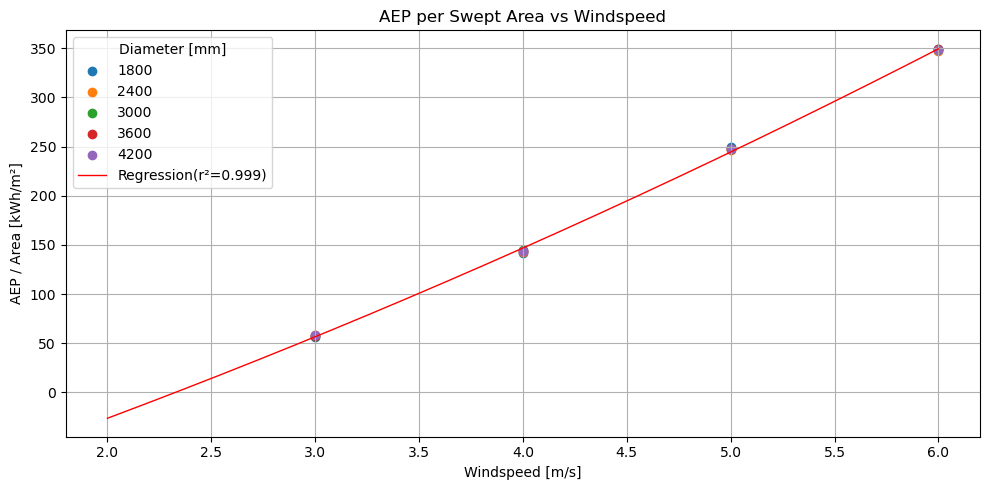

In [6]:
plt.figure(figsize=(10, 5))

for d in diam:
    plt.scatter(AEPperSA_df['Windspeed [m/s]\Diameter [mm]'], AEPperSA_df[d], label=str(d))

x_vals = np.linspace(2, max(AEPperSA_df['Windspeed [m/s]\Diameter [mm]']), 1000)
y_vals = np.polyval(AEP_coeff, x_vals)

plt.plot(x_vals, y_vals, label=f"Regression(r²={round(r2,3)})", color='red', linewidth=1)

plt.xlabel('Windspeed [m/s]')
plt.ylabel('AEP / Area [kWh/m²]')
plt.title('AEP per Swept Area vs Windspeed')
plt.legend(title='Diameter [mm]')
plt.grid(True)
plt.tight_layout()

plt.show()

We can now create the function FU which calculate the energy produced during the lifetime of the wind turbine. 

In [7]:
v_ref = 5 # Annual average windspeed value of site given at h_ref
h_ref = 12.0
z0 = 0.5 # roughness length (urban)
lifetime = 20 # Lifetime of the windturbine

# This function is in symbolic to be compatible with Brightway 2 and lca_algebraic 
def FU(d,h) : 
    v_moy = v_ref*sp.log((h)/z0)/sp.log((h_ref)/z0)
    swept_area = (d * 1e-3)**2 * np.pi / 4
    return np.polyval(AEP_coeff,v_moy)*swept_area*lifetime

#This is the equivalent function in numeric to be compatible with No Load
def FU_numeric(d,h) :
    v_moy = v_ref*np.log(h/z0)/np.log(h_ref/z0)
    swept_area = (d*1e-3)**2*np.pi/4
    return np.polyval(AEP_coeff, v_moy)*swept_area*lifetime



## lca_algebraic parameters

In [8]:
# The diameter of the windturbine
d_min = 1800 
d_max = 4200 
d = agb.newFloatParam(
    "d",
    default = 2400, min = d_min, max = d_max,
    label_fr = "Diameter of the windturbine",
    unit = "mm")

#The height of the mast
h_min = 12
h_max = 24
h = agb.newFloatParam(
    "h",
    default = 18, min = h_min, max = h_max,
    label_fr = "hauteur du mât de l'éolienne",
    unit = "m")


# steel_mix = agb.newEnumParam (
#     "steel_mix",                     # Short name
#     label="Steel production",    # label
#     description="Type of technologies use to produce steel", # Long description
#     values =[                     # Statistic weight of each option that fits with the market
#         "Converter",
#         "Converter_elec"],
#     default = 'Converter'
#     )  


# Parametrization of the inventory

## Sizing of the mast 

In [9]:
height = np.array([h_min, 18, h_max])

# Generate height values
h_values = np.linspace(h_min, h_max, 20) # 20 values of tower height from h_min to h_max

### Fundation

#### Concrete

The volume of concrete depends on the height of the mast and the diameter of the wind turbine. Data from Table 1 and 2 p69. From data in the user manual for a discrete number of combinations of d anf h, a coninuous approximations is generated by fitting a continuous model with a least square regression

In [10]:
nb_concrete_blocs = 5 # from p xxx in user manual 
vec_concrete_volume_per_bloc = np.array([0.3,0.4,0.4,0.5,0.5,0.7,0.5,0.5,0.7,0.7,0.7,1]) # from p xxx in user manual 
vec_concrete_volume_total = vec_concrete_volume_per_bloc*nb_concrete_blocs
list_concrete_volume_total = vec_concrete_volume_total.tolist()


# list comprehension can be used to multiply a list by a scalar
# list_concrete_volume_per_bloc = [0.3,0.4,0.4,0.5,0.5,0.7,0.5,0.5,0.7,0.7,0.7,1]
# list_concrete_volume_total = [Vol*nb_concrete_blocs for Vol in list_concrete_volume_per_bloc]



conc_df = pd.DataFrame({'Diameter':[1800,2400,2400,3000,3000,3000,3600,3600,3600,4200,4200,4200],
                        'Height':[12,12,18,12,18,24,12,18,24,12,18,24],
                        'Volume':list_concrete_volume_total})

a0, a1, a2, a3, a4, a5 = sp.symbols('a0 a1 a2 a3 a4 a5')

f = a0 + a1*h + a2*d + a3*h**2 + a4*h*d + a5*d**2 # symbolic addition of  polynomials of d and h


X = []
y = []

for _, row in conc_df.iterrows():
    hh = row['Height']
    dd = row['Diameter']
    vol = row['Volume']
    X.append([1, hh, dd, hh**2, hh*dd, dd**2])
    y.append(vol)

X = np.array(X)
y = np.array(y)

coeffs, *_ = np.linalg.lstsq(X, y, rcond=None) # fitting parameters with least square

# create symbolic function with parameters from least squares regression
conc_fitted_model = f.subs({
    a0: coeffs[0],
    a1: coeffs[1],
    a2: coeffs[2],
    a3: coeffs[3],
    a4: coeffs[4],
    a5: coeffs[5],
})
# this expression can be evaluated with the command 
# conc_fitted_model.evalf(subs={d:1, h:1})



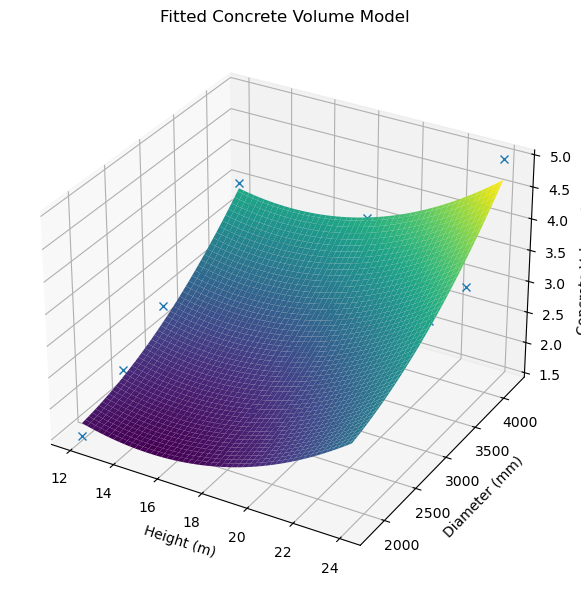

In [11]:

# Convert symbolic function to numerical function
f_lambdified = sp.lambdify((h, d), conc_fitted_model, modules='numpy')

# Create meshgrid for plotting
h_vals = np.linspace(h_min, h_max, 100)
d_vals = np.linspace(d_min, d_max, 100)
H, D = np.meshgrid(h_vals, d_vals)
Z = f_lambdified(H, D)

# Plotting
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(H, D, Z, cmap='viridis', edgecolor='none')
ax.plot(conc_df['Height'], conc_df['Diameter'],conc_df['Volume'], 'x')

ax.set_xlabel('Height (m)')
ax.set_ylabel('Diameter (mm)')
ax.set_zlabel('Concrete Volume (m³)')
ax.set_title('Fitted Concrete Volume Model')

plt.tight_layout()
#plt.savefig("Outputs/Curves/fitted_concrete_volume_model.png", dpi=300)
plt.show()



#### Rebar

From data in the user manual (p XX), a model is fitted to get continuous values for different h and d.

In [12]:
rebar_df = pd.DataFrame({'Height':[12,18,24],
                        'Length':[25,35,50]}) # length or mass ?

rebar_coeff = np.polyfit(rebar_df['Height'],rebar_df['Length'], deg = 2)


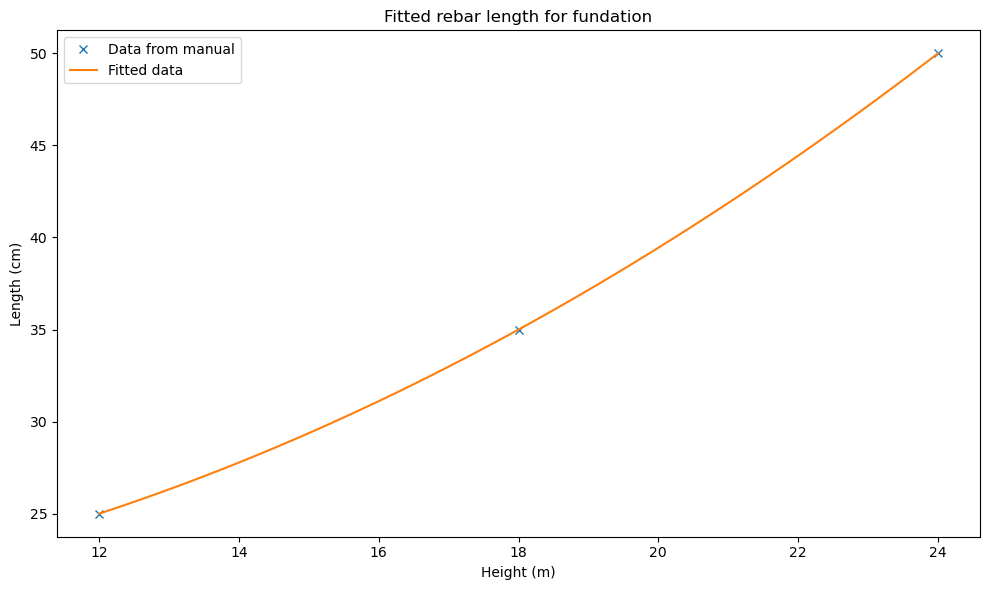

In [13]:
h_vals = np.linspace(h_min, h_max, 100)

#length_fitted = rebar_coeff[0]*h_vals**2+rebar_coeff[1]*h_vals + rebar_coeff[2] 
length_fitted = np.polyval(rebar_coeff,h_vals)

# Plotting
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.plot(rebar_df['Height'], rebar_df['Length'], 'x', label='Data from manual')
ax.plot(h_vals, length_fitted,label='Fitted data')

ax.set_xlabel('Height (m)')
ax.set_ylabel('Length (cm)')
ax.set_title('Fitted rebar length for fundation')
plt.tight_layout()
ax.legend()
#plt.savefig("Outputs/Curves/fitted_rebar_length.png", dpi=300)
plt.show()

###  Steel tower

Steel from the tower is found in the mast, the yaw and the pivot. Regressions are made to obain a continuous for the mass of steel in function of h.

In [14]:
rho_steel = 7850 # steel density kg/m^3

# Mast (from p XX)
e_mast = 3.2e-3 # mast steel tube thickness
D = np.array([88.9,114.3,114.3])*1e-3 # mast steel tube diameters
D_fit=np.polyfit(height,D,1)

#Yaw (from p XX)
e_yaw1 = 0.0029
D_yaw1 = 0.0603

e_yaw2 = 0.0032
D_yaw2 = 0.0889

e_yaw=np.array([e_yaw1, e_yaw2, e_yaw2])
D_yaw=np.array([D_yaw1, D_yaw2, D_yaw2])

D_yaw_fit=np.polyfit(height,D_yaw,1)
e_yaw_fit=np.polyfit(height,e_yaw,1)

#Pivot (from p XX)
e_pivot = 0.005
D_pivot = np.array([60.3,76,76])*1e-3
L_pivot = np.array([395,480,480])*1e-3

D_pivot_fit = np.polyfit(height,D_pivot,1)
L_pivot_fit = np.polyfit(height,L_pivot,1)

# Mass computation from formulas (p XX)
def tower_steel_tube_mass(h):
    
    m_yaw=np.pi*np.polyval(e_yaw_fit,h)*rho_steel*h/2*(np.polyval(D_yaw_fit,h)-np.polyval(e_yaw_fit,h))
    m_mast=np.pi*e_mast*rho_steel*h*(np.polyval(D_fit,h)-e_mast)
    m_pivot = np.pi*e_pivot*rho_steel*np.polyval(L_pivot_fit,h)*(np.polyval(D_pivot_fit,h)-e_pivot)
    
    return m_yaw+m_mast+m_pivot
    
#Real values
def tower_steel_tube_mass_real() : 
    h = np.array([12,18,24])
    m_yaw=np.pi*e_yaw*rho_steel*h/2*(D_yaw-e_yaw)
    m_mast=np.pi*e_mast*rho_steel*h*(D-e_mast)
    m_pivot = np.pi*e_pivot*rho_steel*L_pivot*(D_pivot-e_pivot)

    return m_mast+m_yaw+m_pivot

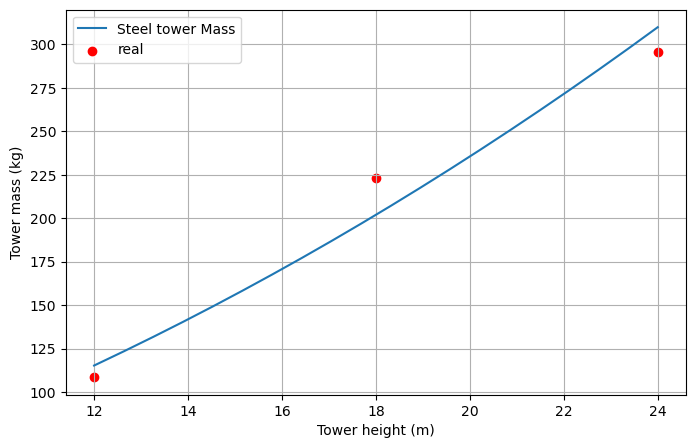

In [15]:
# Plot the functions to compare approximation an real values
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(h_values, tower_steel_tube_mass(h_values), label="Steel tower Mass")
ax.scatter(height,tower_steel_tube_mass_real(),label='real',color = 'red')
ax.set_xlabel('Tower height (m)')
ax.set_ylabel('Tower mass (kg)')
ax.grid(True)
ax.legend()
plt.show()

### Rigging

#### Guy wire

##### **Mass**

For the length of the top guy wires $L_c$, we have : 

$L_c = \frac{4h}{\sin(\alpha)} = \frac{8h}{\sqrt3}$

with : 

$\alpha = 60°$ the angle formed between the cable and the ground

$h$ the mast height

Smaller cable are used to strengthen the mast tube with a diameter considered constant of 6 mm. They are connected to the same anchorage as the top cable but they are connected to the mast at 6 m, 12 m and 18 m with a length of $\lambda_1$, $\lambda_2$ and $\lambda_3$.

$\lambda_1 = 4\sqrt{\left(\frac{L}{2}\right)^2+6^2}$

$\lambda_2 = 4\sqrt{\left(\frac{L}{2}\right)^2+12^2}$


$\lambda_3 = 4\sqrt{\left(\frac{L}{2}\right)^2+18^2}$


In [16]:
#fill factor of the wires, which translates that there is gaps in the section
k_wire = 0.51

#This coefficient between 0 an 1 defines at which point between 2 height from the handbook, for example 12m and 18m,
#do we add a third layer of cable
coef_add_cable = 0.5

#Function which gives the length of wires in relation to the height of the mast, with a step at each new layer of guy wires.
def length_wire_steel_step(h):
    L6 = 4 * sp.sqrt((12 / 2) ** 2 + (6) ** 2)
    LT = 8 * h / sp.sqrt(3) #Lenght of wires fixed at the top
    L12 = sp.Piecewise((4 * sp.sqrt((h / 2) ** 2 + 12 ** 2), h > 12+6*coef_add_cable), (0, True))#Lenght of guy wires fixed at 12m
    L18 = sp.Piecewise((4 * sp.sqrt((h / 2) ** 2 + 18 ** 2), h > 18+6*coef_add_cable), (0, True))#Lenght of guy wires fixed at 18m
    L24 = sp.Piecewise((4 * sp.sqrt((h / 2) ** 2 + 24 ** 2), h > 24+6*coef_add_cable), (0, True))#Lenght of guy wires fixed at 24m
    return L6 + LT + L12 + L18 + L24

def mass_wire_steel_step(h):
    S_6 = k_wire * sp.pi * (0.006 / 2) ** 2
    return rho_steel * S_6 * length_wire_steel_step(h)

# The regression has been made on a separate sheet
def length_wire_steel_regression(h):
    return 38.6 + -2.56*h + 0.564*h**2

def mass_wire_steel(h):
    S_6 = k_wire * sp.pi * (0.006 / 2) ** 2
    return rho_steel * S_6 * length_wire_steel_regression(h)



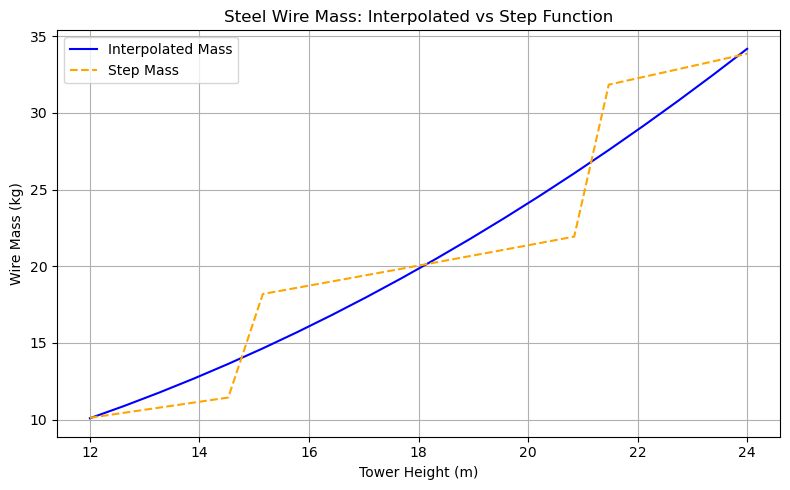

In [17]:
# comparison : regression and real values

# Lambdify the function
m_wire_step_expr = mass_wire_steel_step(h)
m_wire_step_numeric = sp.lambdify(h, m_wire_step_expr, 'numpy')

# Compute values
m_wire_regression_values = mass_wire_steel(h_values)
m_wire_step_values = m_wire_step_numeric(h_values)

# Plot both
plt.figure(figsize=(8,5))
plt.plot(h_values, m_wire_regression_values, label="Interpolated Mass", color='blue')
plt.plot(h_values, m_wire_step_values, label="Step Mass ", color='orange', linestyle='--')
plt.xlabel('Tower Height (m)')
plt.ylabel('Wire Mass (kg)')
plt.title('Steel Wire Mass: Interpolated vs Step Function')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


##### **Zinc coating**

In [18]:
D_wire = 0.006 # diametre cable
#A = D_wire**2/4*np.pi #Coated area per meter of cable
A = D_wire**2*np.pi

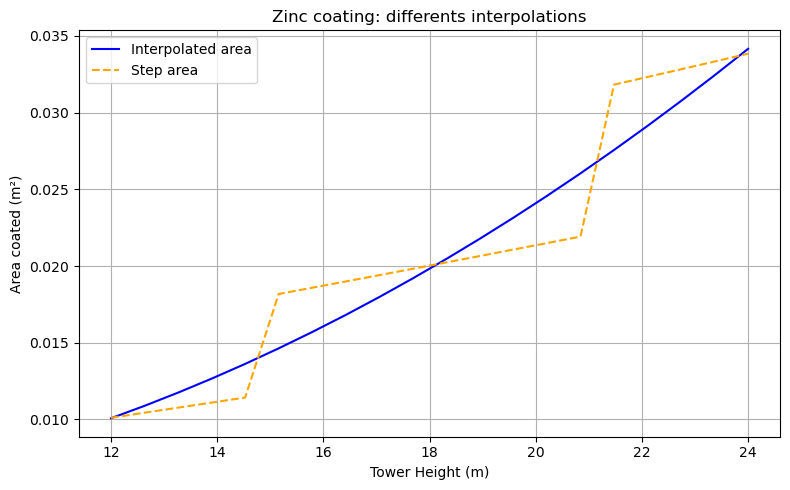

In [19]:
# Lambdify function for the plot

l_wire_step_expr = length_wire_steel_step(h)
l_wire_step_numeric = sp.lambdify(h, l_wire_step_expr, 'numpy')

# Compute values
l_values = length_wire_steel_regression(h_values)
l_step_values = l_wire_step_numeric(h_values)

# Plot both
plt.figure(figsize=(8,5))
plt.plot(h_values, A*l_values, label="Interpolated area", color='blue')
plt.plot(h_values, A*l_step_values, label="Step area ", color='orange', linestyle='--')
plt.xlabel('Tower Height (m)')
plt.ylabel('Area coated (m²)')
plt.title('Zinc coating: differents interpolations')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Hardware

All the screws, nuts, cable clamp etc. used to build the structure. Most of the weight come from the hardware for the rigging. Pieces are galvanised.


In [20]:
hardware_struct_df = pd.DataFrame({
    'Height': [12, 18, 24],
    'Mass':   [12.2, 18.1, 23.2]  # Zinc hardware mass in kg
})

spec_surf = 60/1000 #Specific surface of the hardawre in kg/m². The value 60 t/m² come from the documentation of 
                    # the activity zinc coating, piece, ReR

hardware_struct_coeff = np.polyfit(hardware_struct_df['Height'], hardware_struct_df['Mass'], deg=1)



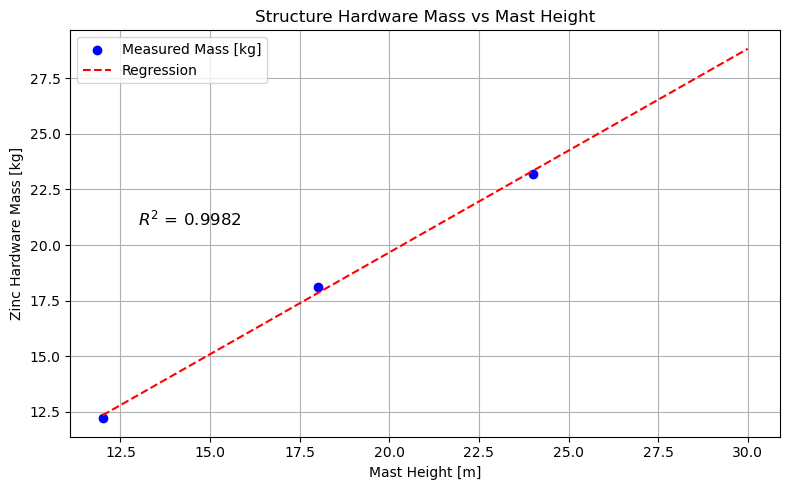

In [21]:


x = hardware_struct_df['Height']
y = hardware_struct_df['Mass']
y_pred = np.polyval(hardware_struct_coeff, x)

# Compute R²
r2 = r2_score(y, y_pred)

x_fit = np.linspace(12, 30, 200)
mass_fit = np.polyval(hardware_struct_coeff, x_fit)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Measured Mass [kg]')
plt.plot(x_fit, mass_fit, color='red', linestyle='--', label='Regression')
plt.xlabel('Mast Height [m]')
plt.ylabel('Zinc Hardware Mass [kg]')
plt.title('Structure Hardware Mass vs Mast Height')
plt.text(13, max(y)*0.9, f'$R^2$ = {r2:.4f}', fontsize=12, color='black')  # R² display
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Sizing of the wind generator

The regressions are based on an output from the software OpenAFPM, specifically a .FCStd file create with OpenAFPM CAD. All the volumes are then extracted in a .csv file with the code export-volumes.py.

For some elements, such as the wood for blades, the regression is directly made with the data of the handbook.

In [22]:
#Volumic mass in kg/cm³

sm_glassfibre = 0.07 #surfacic mass of the glass fibre in kg/m²
vm_copper = 8960 * 1e-6
vm_mgn = 7500 * 1e-6
vm_plywood = 500 * 1e-6
vm_resin = 1360 * 1e-6
vm_softwood = 500*1e-6 #Typical volumic mass for douglas or cedar 
vm_steel = 7850 * 1e-6

In [23]:
#Excrating volumes from .csv files
vol_pd = pd.read_csv(f"SizingWT/Volume_csv/volumes_1800.csv") #Change this if you need
for a in [2400,3000,3600,4200] : 
    vol1_pd = pd.read_csv(f"SizingWT/Volume_csv/volumes_{a}.csv")
    vol_pd = pd.merge(vol_pd,vol1_pd, on='Diameter',how='outer')
vol_pd = vol_pd.fillna(0)
vol_pd = vol_pd.iloc[1:].copy()
vol_pd.columns = ['Component', 1800, 2400, 3000, 3600, 4200]
vol_pd = vol_pd.set_index('Component')
vol_pd = vol_pd.astype(float)
save_data = vol_pd.to_csv('vol_pd.csv', index = True)
vol_pd

,1800,2400,3000,3600,4200
Component,,,,,
WindTurbine,"8,237.2","14,628.6","21,097.7","30,430.5","38,745.7"
WindTurbine/Alternator,"4,573.68","7,096.71","10,160.9","13,578.2","14,186.1"
WindTurbine/Alternator/Blade_Assembly_BackDisk,274.94,582.91,"1,154.83","1,999.62","2,737.18"
WindTurbine/Alternator/Blade_Assembly_FrontTriangle,290.54,666.07,"1,294.4","2,228.19",349.04
WindTurbine/Alternator/Blade_Assembly_FrontTriangle/InnerHoleScrewHoleMultiTransform,290.54,666.07,"1,294.4","2,228.19",349.04
...,...,...,...,...,...
WindTurbine/YawBearing/Plate_Top,45.66,61.59,72.48,0,0
WindTurbine/YawBearing/SafetyCatchPart,5.85,8.37,10.99,14.15,16.42
WindTurbine/YawBearing/SafetyCatchPart/SafetyCatch,5.85,8.37,10.99,14.15,16.42


In [24]:
#element_df = pd.DataFrame(columns = ['Element','1800','2400','3000','3600','4200'])
element_df =  pd.DataFrame()

### Computation of masses

#### Propeller

In [25]:
v_blades_data = np.array([95.0*35.0*900.0, 125.0*40.0*1200.0, 145.0*45.0*1500.0, 195.0*60.0*1800.0, 225.0*75.0*2100.0])*1e-3 #blades volume [cm^3] From the Tripalium handbook 2023, p14 Table 1
number_of_blades=3
m_blades_data = v_blades_data*vm_softwood*number_of_blades
m_blades = pd.Series(np.concatenate([m_blades_data,np.array(['kg'])]), index = [1800, 2400, 3000, 3600, 4200,'unit'])
m_blades.name = "Blades"
element_df = element_df._append(m_blades)

vol_bladesAttachements = 1e-6*(vol_pd.loc['WindTurbine/Alternator/Blade_Assembly_BackDisk']+vol_pd.loc['WindTurbine/Alternator/Blade_Assembly_FrontTriangle'])
vol_bladesAttachements.name = "BladesAttachement"
vol_bladesAttachements[3600] = 2900.0*1e-6
vol_bladesAttachements['unit']='m³'
element_df = element_df._append(vol_bladesAttachements)

#### Stator

In [26]:
k_copper = 0.55 #Fill factor
v_coils = vol_pd.loc['WindTurbine/Alternator/Stator/Coils']*k_copper
m_coils = v_coils*vm_copper
m_coils.name = "CopperCoils"
m_coils['unit']='kg'
element_df = element_df._append(m_coils)


m_resinS =  vol_pd.loc['WindTurbine/Alternator/Stator/ResinCast']*vm_resin
m_resinS.name = 'ResinStator'
m_resinS['unit'] = 'kg'
element_df = element_df._append(m_resinS)

#### Rotor

In [27]:
number_of_rotor_disks=2 # to do parametrize this at the beginning
v_metaldisks = vol_pd.loc['WindTurbine/Alternator/Rotor_Back/Rotor_Disk_Back']*number_of_rotor_disks # total volume of rotor disks
m_metaldisks = v_metaldisks*vm_steel             
m_metaldisks.name = 'MetalDisks'
m_metaldisks['unit']='kg'
element_df = element_df._append(m_metaldisks)

e_disk = [6*0.001,8*0.001,10*0.001,10*0.001,10*0.001] #Find the thickness of the disk p106 # to do : check thickness value for 3m design
s_metaldisk = v_metaldisks[:5]/e_disk #total surface of 
s_metaldisk.name = 'SurfaceDisk'
s_metaldisk['unit'] = 'm²'
element_df = element_df._append(s_metaldisk)

m_mgn = vol_pd.loc['WindTurbine/Alternator/Rotor_Back/MagnetResin_Assembly/Rotor_Magnets']*vm_mgn # to do : check 
m_mgn.name = 'Magnet'
m_mgn2 = m_mgn.copy()
m_mgn2[1:] = m_mgn[1:]*2 # to do : check if the case where single rotor with metal disk is taken into account
m_mgn2['unit']='kg'
element_df = element_df._append(m_mgn2)

m_resinR = vol_pd.loc['WindTurbine/Alternator/Rotor_Back/MagnetResin_Assembly/Rotor_ResinCast']*vm_resin
m_resinR.name = 'ResinRotor'
m_resinR2 = m_resinR.copy()
m_resinR2[1:] = m_resinR[1:]*2 # to do : check 
m_resinR2['unit']='kg'
element_df = element_df._append(m_resinR2)

#### Hub

In [28]:
v_hub = vol_pd.loc['WindTurbine/Alternator/Hub']*1e-6
v_hub.name = 'Hub'
v_hub['unit']='m³'
element_df = element_df._append(v_hub)

#### Tail

In [29]:
v_vane = vol_pd.loc['WindTurbine/Tail_Assembly/Tail/Assembly_BoomVane/Vane']*1e-6
v_vane.name = 'Vane'
v_vane['unit']='m³'
element_df = element_df._append(v_vane)

m_boompipe = vol_pd.loc['WindTurbine/Tail_Assembly/Tail/Assembly_BoomVane/Boom_Pipe']*vm_steel
m_boompipe.name = 'BoomPipe'
m_boompipe['unit']='kg'
element_df = element_df._append(m_boompipe)

m_hingeouter = vol_pd.loc['WindTurbine/Tail_Assembly/Tail/Hinge_Outer']*vm_steel
m_hingeouter.name = 'HingeOuter'
m_hingeouter['unit']='kg'
element_df = element_df._append(m_hingeouter)

m_steel4tail = vm_steel*(vol_pd.loc['WindTurbine/Tail_Assembly/Tail/Assembly_BoomVane/Vane_Bracket_Bottom']*2+vol_pd.loc['WindTurbine/Tail_Assembly/Tail/Assembly_BoomVane/Boom_Support']
+vol_pd.loc['WindTurbine/Tail_Assembly/Tail/Assembly_BoomVane/Tail_Stop_HighEnd']+vol_pd.loc['WindTurbine/Tail_Assembly/Tail/Hinge_Outer/Tail_Stop_LowEnd'])
m_steel4tail.name = 'Bracket+Support+TailStop'
m_steel4tail['unit']='kg'
element_df = element_df._append(m_steel4tail)

#### Nacelle

In [30]:
m_frame = vol_pd.loc['WindTurbine/Alternator/Frame']*vm_steel
m_frame.name = 'Frame'
m_frame['unit']='kg'
element_df = element_df._append(m_frame)

m_yawpipe = vol_pd.loc['WindTurbine/YawBearing/Pipe']*vm_steel
m_yawpipe.name = 'YawPipe'
m_yawpipe['unit']='kg'
element_df = element_df._append(m_yawpipe)

m_yamplate = vm_steel*(vol_pd.loc['WindTurbine/YawBearing/Plate_Top']+vol_pd.loc['WindTurbine/YawBearing/SafetyCatchPart']+vol_pd.loc['WindTurbine/YawBearing/Side']+vol_pd.loc['WindTurbine/YawBearing/Top'])
m_yamplate.name = 'YawPlates'
m_yamplate['unit']='kg'
element_df = element_df._append(m_yamplate)

#### Hardware

In [31]:
m_hardware_inox = pd.Series([2.480361126,2.592621126,2.661621126,4.594967228,4.798127228,'kg'],index = [1800, 2400, 3000, 3600, 4200,'unit'])
m_hardware_inox.name = 'Hardware inox'
element_df = element_df._append(m_hardware_inox)

m_hardware_zinc = pd.Series([2.666036318,2.666036318,2.666036318,2.717936318,2.717936318,'kg'],index = [1800, 2400, 3000, 3600, 4200,'unit'])
m_hardware_inox.name = 'Hardware inox'
m_hardware_zinc.name = 'Hardware zinc'
m_hardware_zinc['unit']='kg'
element_df = element_df._append(m_hardware_zinc)

#### Other elements

Data from Table 3 and 4 p42-43

In [32]:
v_mould_stator = pd.Series([0.45*0.45*(0.0015*2+0.012),0.55*0.55*(0.0015*2+0.012),0.6*0.6*(0.0015*2+0.012),0.65*0.65*(0.0015*2+0.012),0.7*0.7*(0.0015*2+0.012),'m³']
                           ,index = [1800, 2400, 3000, 3600, 4200,'unit']) # 2 planks of 15mm and one of 12mm
v_mould_stator.name = "MouldStator"
element_df = element_df._append(v_mould_stator)

v_mould_rotor = pd.Series([0.35*0.35*(0.015+0.006+0.016),0.4*0.4*(0.015+0.006+0.02),0.5*0.5*(0.015+0.006+0.02),0.5*0.5*(0.015+0.006+0.02),0.6*0.6*(0.015+0.006+0.02),'m³'],index = [1800, 2400, 3000, 3600, 4200,'unit'])
v_mould_rotor.name = "MouldRotor"
element_df = element_df._append(v_mould_rotor)

#### All quantities

In [33]:
element_df

,1800,2400,3000,3600,4200,unit
Blades,4.4887500000000005,9.0,14.681249999999999,31.589999999999996,53.15625,kg
BladesAttachement,0.00056548,0.00124898,0.00244923,0.0029,0.00308622,m³
CopperCoils,2.30123,2.63377,4.25424,4.65464,6.08588,kg
ResinStator,1.49529,1.78267,2.43537,2.9716,3.58214,kg
MetalDisks,7.1391,10.5352,14.7161,19.5939,24.1304,kg
SurfaceDisk,"151,573","167,758","187,466","249,604","307,394",m²
Magnet,0.823875,2.47155,2.47155,3.2955,3.2955,kg
ResinRotor,0.559327,1.69247,2.27552,2.40222,2.70025,kg
Hub,0.00039774,0.00039774,0.00039774,0.00055104,0.00055974,m³
Vane,0.00243311,0.00600753,0.00909618,0.0141209,0.0212644,m³


### Regression

In [34]:
regression_df = pd.DataFrame(columns=['Component','Regression','r2','unit'])
for i in range(len(element_df)) : 
    r = element_df.iloc[i][:5]
    r=r.astype(float)
    r.index = r.index.astype(float)
    v_coeff= np.polyfit(r.index,r.values, deg = 2)
    v_reg = np.polyval(v_coeff,r.index)
    r2 = r2_score(r.values,v_reg)
    new_row = {"Component":element_df.index[i],"Regression":v_coeff,"r2":r2,"unit":element_df.iloc[i]['unit']}
    regression_df=regression_df._append(new_row,ignore_index=True)
regression_df = regression_df.set_index('Component')
regression_df

/tmp/ipykernel_99698/139220996.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  regression_df=regression_df._append(new_row,ignore_index=True)


,Regression,r2,unit
Component,,,
Blades,"[8.99553571428567e-06, -0.033985714285714064, ...",0.996751,kg
BladesAttachement,"[-3.4603968253967805e-10, 3.1916547619047387e-...",0.978161,m³
CopperCoils,"[1.9391288888889042e-07, 0.0004348866133333243...",0.965594,kg
ResinStator,"[1.0513285714285758e-07, 0.000262974457142855,...",0.994871,kg
MetalDisks,"[5.908371031746057e-07, 0.0036285428809523694,...",0.999249,kg
SurfaceDisk,"[0.02492880291005285, -83.99151190476164, 2224...",0.993357,m²
Magnet,"[-4.903571428571385e-07, 0.003903342857142835,...",0.923811,kg
ResinRotor,"[-4.219399999999953e-07, 0.0033635746666666423...",0.980452,kg
Hub,"[3.3869047619047476e-11, -1.2366428571428495e-...",0.83259,m³


### Plot

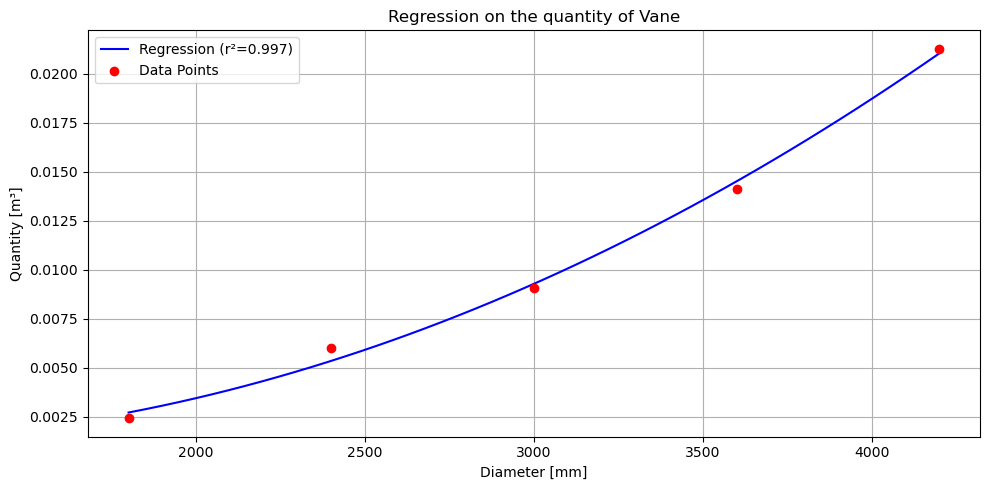

In [35]:
elem = 'Vane' #Change the name to plot other elements 
# Plotting
r = element_df.loc[elem][:5]
r2 = regression_df.loc[elem]['r2']
v_coeff = regression_df.loc[elem].iloc[0]
diam_range = np.linspace(min(diam), max(diam), 50)
x_vals =diam_range
y_vals = np.polyval(v_coeff,x_vals)


plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label=f"Regression (r²={round(r2,3)})", color='blue')
plt.scatter(diam,r.values , color='red', label="Data Points", zorder=5)
plt.xlabel("Diameter [mm]")
plt.ylabel(f"Quantity [{element_df.loc[elem]['unit']}]")
plt.title(f"Regression on the quantity of {elem}")
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig(f"Outputs/Curves/reg_{elem}.png", dpi=300)
plt.show()

Now the mass model of the wind turbine is complete. Next step is to link theses functions to activities in the Ecoinvent database.

# Activities

In [36]:
# Be careful there is no recursive action in the axis use. Each activity should have an axis label otherwise it won't be counted. If there is no label then the activity is not consider in the calculation. For example, for the axis "system", each sub-activity should get the label "strc" or "wg" not only the activity "structure assembly" and "wind generator assembly" 


# axis : System 
# strc = "Structure"
# wg = "WindGenerator"


# axis : Subsystem structure
rigging = "Rigging"
mast = "Mast"
fundation = "Fundation"
#elec = "Electronics"

# axis : Subsystem wind generator
prop = "Propeller"
stat = "Stator"
rot = "Rotor"
#hub = "Hub"
tail = "Tail"
nac = "Nacelle"
hard = "Hardware"
cable = "Cable" # modif
mould = "Moulds"

# axis : Materials
conc = "Concrete"
copper_coil = "Copper (windings)" # new
copper_cable = "Copper (cable)" # new 
ix = "Inox"
mgn = "Magnet"
resin = "Resin"
steel = "Steel"
wood = "Wood"
zc_c = "Zinc coating"
plastic = "Plastic"



## Steel mix (not used)

The purpose here is to create a switching activity to represent the different steel supply chains. Still under development

In [37]:
Steel_un_converter_ecoinvent = agb.findTechAct("steel production, converter, unalloyed","RER")
Steel_low_converter_ecoinvent = agb.findTechAct("steel production, converter, low-alloyed","RER")
#steel_low_elec_ecoinvent = agb.findTechAct("steel production, electric, low-alloyed","Europe without Switzerland and Austria")

# steel_un_mix = agb.newActivity(
#      DB_SYST,
#     "Production of unalloyed steel in Europe",
#     unit = "kg",
#     exchanges = {
#         steel_un_converter_ecoinvent : 0.55,
#         steel_low_elec_ecoinvent : 0.45,
#     })

# steel_low_mix = agb.newActivity(
#      DB_SYST,
#     "Production of low alloyed steel in Europe",
#     unit = "kg",
#     exchanges = {
#         steel_low_converter_ecoinvent : 0.55,
#         steel_low_elec_ecoinvent : 0.45,
#     })

# steel_un_choice = agb.newSwitchAct(
#                     DB_SYST, # Database where the new activity is created
#                     "Choice of mix for steel unalloyed production",
#                     steel_mix, #enum parameter that is used to switch the activity
#                             {
#                                 "Converter":steel_un_converter_ecoinvent,
#                                 "Converter_elec": steel_un_mix,
#                             })

# steel_low_choice = agb.newSwitchAct(
#                     DB_SYST, # Database where the new activity is created
#                     "Choice of mix for steel lowalloyed production",
#                     steel_mix, #enum parameter that is used to switch the activity
#                             {
#                                 "Converter":steel_low_converter_ecoinvent,
#                                 "Converter_elec": steel_low_mix,
#                             })


# steel_un = agb.newActivity(
#     DB_SYST,
#     "steel, unalloyed",
#     unit = "kg",
#     exchanges = {
#         #steel_un_choice : 1
#         steel_un_converter_ecoinvent : 1
#     })

# steel_low = agb.newActivity(
#     DB_SYST,
#     "steel, low alloyed",
#     unit = "kg",
#     exchanges = {
#         #steel_low_choice :1
#         steel_low_converter_ecoinvent
#     })


## Structure

### Fundation

In [38]:
Concrete_ecoinvent = agb.findTechAct("concrete, all types to generic market for concrete, normal strength","RoW")

Concrete = agb.newActivity(
    DB_SYST,
    "Concrete for fundation",
    unit = "m³",
    subsystem = fundation,
    material = conc,
    exchanges = {
        Concrete_ecoinvent : 1,}
    )

In [39]:
Reinforced_steel_ecoinvent = agb.findTechAct("reinforcing steel production","Europe without Austria")

Rebar_HA10 = agb.newActivity(
    DB_SYST,
    "Concrete reinforcing bar HA10",
    unit = "unit",
    subsystem = fundation,
    material = steel,
    exchanges = {
        Reinforced_steel_ecoinvent : np.polyval(rebar_coeff,h),
    })


Zinc_coating_ecoinvent = agb.findTechAct("zinc coating, pieces","RER")

Zinc_coating_anchor = agb.newActivity(
    DB_SYST,
    "Zinc coating anchor",
    unit = "m²",
    subsystem = fundation,
    material = zc_c,
    exchanges = {Zinc_coating_ecoinvent : 1}
    )

Anchor_unzinc = agb.newActivity(
    DB_SYST,
    "Anchor, not galvanised",
    unit = "unit",
    subsystem = fundation,
    material = steel,
    exchanges = {
        Reinforced_steel_ecoinvent : 8.5 *1.578, # Length * linear mass  (p xx in the user manual)
    })

Anchor = agb.newActivity(
    DB_SYST,
    "Anchor, galvanised",
    unit = "unit",
    subsystem = fundation,
    exchanges = {
        Anchor_unzinc : 1,
        Zinc_coating_anchor : np.pi*8.5*0.016 # Length * Pi* Diameter  (p xx in the user manual)
    })

Fundation = agb.newActivity(
    DB_SYST,
    "Fundation assembly",
    unit = "unit",
    subsystem = fundation,
    exchanges = {
        Concrete : conc_fitted_model,
        Rebar_HA10 : 1,
        Anchor : 1,
    })

### Mast

In [ ]:
Drawing_of_pipe_ecoinvent = agb.findTechAct("drawing of pipe, steel","RER")

Steel_tube_mast = agb.newActivity(
    DB_SYST,
    name="Steel tube mast activity",
    unit="kg",
    subsystem = mast,
    material = steel,
    exchanges = {
        #steel_un : 1,
        Steel_un_converter_ecoinvent : 1,
        Drawing_of_pipe_ecoinvent : 1,
    })

Av_work_steel_ecoinvent = agb.findTechAct("metal working, average for steel product manufacturing","RER")


Swivel_pin_unzinc = agb.newActivity(
    DB_SYST,
    name="Threaded rod, not galvanised, for the swivel pin",
    unit="unit",
    subsystem = mast,
    material = steel,
    exchanges = {
        #steel_low : rho_steel*np.pi*0.018**2/4*1, # volume de tige filetee pour 1 m de tige
        Steel_low_converter_ecoinvent : rho_steel*np.pi*0.018**2/4*1, # From p XX in the user manual
        Av_work_steel_ecoinvent: rho_steel*np.pi*0.018**2/4*1 
    })

Zinc_coating_mast = agb.newActivity(
    DB_SYST,
    "Zinc coating mast activity",
    unit = "m²",
    subsystem = mast,
    material = zc_c,
    exchanges = {Zinc_coating_ecoinvent : 1}
    )


Swivel_pin = agb.newActivity(
    DB_SYST,
    name="Threaded rod galvanised for the swivel pin",
    unit="unit",
    subsystem = mast,
    exchanges = {
        Swivel_pin_unzinc:1,
        Zinc_coating_mast : np.pi*0.018*1,    # From p XX in the user manual
    })
    
Gusset = agb.newActivity(
    DB_SYST,
    name="Gussets activity",
    unit="kg",
    subsystem = mast,
    material = steel,
    exchanges = {
        #steel_un : 1,
        Steel_un_converter_ecoinvent : 1,
    })
Base = agb.newActivity(
    DB_SYST,
    name="Mast base",
    unit="unit",
    subsystem = mast,
    material = steel,
    exchanges = {
        #steel_un : rho_steel*1*0.1*0.01+rho_steel*1*0.06*0.008*2,
        Steel_un_converter_ecoinvent : rho_steel*1*0.1*0.01+rho_steel*1*0.06*0.008*2 # From p XX in the user manual
    })

Welding_ecoinvent = agb.findTechAct("welding, arc, steel","RER")

Welding = agb.newActivity(
    DB_SYST,
    name="Arc welding",
    unit="m",
    subsystem = mast,
    material = steel,
    exchanges = {
        Welding_ecoinvent : 1,
    })

    
Mast = agb.newActivity(
    DB_SYST,
    name="Mast of height h, assembly",
    unit="unit",
    #system = strc,
    subsystem = mast,
    exchanges = {
        Steel_tube_mast : tower_steel_tube_mass(h),
        Swivel_pin : 1,
        Gusset : rho_steel*(0.113*h + 0.68)*0.05*0.008, # From p XX in the user manual
        Base : 1,
        Welding : 5
    })

### Rigging

In [41]:
Zinc_coating_rigging = agb.newActivity(
    DB_SYST,
    "Zinc coating rigging activity",
    unit = "m²",
    subsystem = rigging,
    material = zc_c,
    exchanges = {Zinc_coating_ecoinvent : 1}
    )


Hardware_unzinc_rigging = agb.newActivity(
    DB_SYST,
    "Hardware for rigging, not galvanised",
    unit = "unit",
    subsystem = rigging,
    material = steel,
    exchanges = { 
        #steel_low : 0.92*h+1.28, 
        Steel_low_converter_ecoinvent : np.polyval(hardware_struct_coeff, h),
        Av_work_steel_ecoinvent : np.polyval(hardware_struct_coeff, h)
    })

Hardware_zinc_rigging = agb.newActivity(
    DB_SYST,
    "Hardware for rigging, galvanised",
    unit = "unit",
    subsystem = rigging,
    exchanges = { 
       Hardware_unzinc_rigging : 1,
       Zinc_coating_rigging : 0.0552*h+0.0771 # regression manuelle de fichier excel 
    })


Steel_wire_drawing_ecoinvent = agb.findTechAct("wire drawing, steel","RER")

Guy_wire_unzinc = agb.newActivity(
    DB_SYST,
    "Guy wires, not galvanised",
    unit = "unit",
    subsystem = rigging,
    material = steel,
    exchanges = { 
        #steel_un : mass_wire_steel(h),
        Steel_un_converter_ecoinvent : mass_wire_steel(h),
        Steel_wire_drawing_ecoinvent : mass_wire_steel(h),
    })

Guy_wire = agb.newActivity(
    DB_SYST,
    "Guy wires, galvanised",
    unit = "unit",
    subsystem = rigging,
    exchanges = {
        Guy_wire_unzinc : 1,
        Zinc_coating_rigging : A*length_wire_steel_regression(h)
    })

Guy_wire_distributor = agb.newActivity(
    DB_SYST,
    "Guy wires distributors activity",
    unit = "unit",
    subsystem = rigging,
    material = steel,
    exchanges = { 
       # steel_low : rho_steel*0.15*0.008*1.2,
        #steel_low : rho_steel*0.15*0.008*4*0.3, # p 74 manuel
        Steel_low_converter_ecoinvent : rho_steel*0.15*0.008*4*0.3, # p 74 manuel
    })
    
Rigging = agb.newActivity(
    DB_SYST,
    "Rigging assembly",
    unit = "unit",
    subsystem = rigging,
    exchanges = { 
        Hardware_zinc_rigging : 1,
        Guy_wire : 1,
        Guy_wire_distributor : 1,
    })

### Cable 48V

Modelling of the cable come from the work of A.Prévost

In [ ]:
Copper_cathode_ecoinvent = agb.findTechAct("market for copper, cathode","GLO")
Copper_wire_drawing_ecoinvent = agb.findTechAct("wire drawing, copper","RER")

Copper_wire_cable = agb.newActivity(
    DB_SYST,
    "Copper wires for cable",
    unit ="unit/m",
    subsystem = cable,
    material = copper_cable,
    exchanges = {
        Copper_cathode_ecoinvent : 8960*3*0.000004, # parametrization par la section du cable (p XX in the user manual)
        Copper_wire_drawing_ecoinvent : 8960*3*0.000004, # parametrization par la section du cable
    })
    
Polyethylene_ecoinvent = agb.findTechAct("polyethylene production, high density, granulate","RER")
Extrusion_plastic_ecoinvent = agb.findTechAct("extrusion, plastic pipes","RER")
Machine_ecoinvent = agb.findTechAct("rolling mill production","RER")
#Tap_water_ecoinvent= agb.findTechAct("market for tap water","Europe without Switzerland")

Plastic = agb.newActivity(
    DB_SYST,
    "Plastic cover",
    unit = "unit/m",
    subsystem = cable,
    material = plastic,
    exchanges = {
        Polyethylene_ecoinvent : 0.011848, # parametrization par la section du cable  (p XX in the user manual)
        Extrusion_plastic_ecoinvent : 0.011848,
        Machine_ecoinvent : 0.000000000021234/h, # parametrization par la section du cable (puis masse)
        #Tap_water_ecoinvent : 17.424/12,
    })
Cable_48V = agb.newActivity(
    DB_SYST,
    "Cable 48V activity",
    unit='unit/m',
    subsystem = cable,
    exchanges = {
        Copper_wire_cable : 1,
        Plastic : 1,
    })

### Complete structure

In [43]:
Structure = agb.newActivity(
    DB_SYST,
    name="Structure assembly",
    unit="unit",
    exchanges = {
        Fundation : 1,
        Mast : 1,
        Rigging : 1,
        Cable_48V : h,
    })



## Wind generator

### Propeller

In [44]:
Swood_ecoinvent = agb.findActivity(name = "planing, beam, softwood, u=20%",loc = "Europe without Switzerland",db_name = "ecoinvent-3.8-cutoff",unit ="kilogram")
Plywood_ecoinvent = agb.findActivity(name = "plywood production",loc = "RER",db_name = "ecoinvent-3.8-cutoff", unit ="cubic meter")


Propeller = agb.newActivity(
    DB_SYST,
    name="Propeller planing",
    unit="unit",
    subsystem = prop,
    material = wood,
    exchanges = {
        Swood_ecoinvent : np.polyval(regression_df.loc['Blades'].iloc[0],d),
        Plywood_ecoinvent :  np.polyval(regression_df.loc['BladesAttachement'].iloc[0],d)*1e-6,
    })

### Rotor

In [45]:
Metal_disk_unzinc = agb.newActivity(
    DB_SYST,
    "Metal disks, unzinc activity",
    unit = "unit",
    subsystem = rot,
    material = steel,
    exchanges = {
        #steel_un : np.polyval(regression_df.loc['MetalDisks'].iloc[0],d),
        Steel_un_converter_ecoinvent : np.polyval(regression_df.loc['MetalDisks'].iloc[0],d),
    })


Zinc_coating_rotor = agb.newActivity(
    DB_SYST,
    "Zinc coating rotor activity",
    unit = "m²",
    subsystem = rot,
    material = zc_c,
    exchanges = {Zinc_coating_ecoinvent : 1}
    )    

Metal_disk = agb.newActivity(
    DB_SYST,
    "Metal disks, galvanised ",
    unit = "unit",
    subsystem = rot,
    exchanges = {
        Metal_disk_unzinc : 1,
        Zinc_coating_rotor : np.polyval(regression_df.loc['SurfaceDisk'].iloc[0],d),
    })

    
Mgn_neo_ecoinvent = agb.findTechAct("permanent magnet production, for electric motor","GLO") #neodym magnet

Magnet = agb.newActivity(
    DB_SYST,
    "Magnet activity",
    unit = "unit",
    subsystem = rot,
    material = mgn,
    exchanges = {
        Mgn_neo_ecoinvent : np.polyval(regression_df.loc['Magnet'].iloc[0],d)
    })

Iso_resin_ecoinvent = agb.findTechAct("isophthalic acid based unsaturated polyester resin production","RER")
Talc_ecoinvent = agb.findTechAct("steatite quarry operation","RoW")
Glass_fibre_ecoinvent = agb.findTechAct("glass fibre production","RER")

def resinS_mass(d) : return np.polyval(regression_df.loc['ResinStator'].iloc[0],d)
def resinR_mass(d) : return np.polyval(regression_df.loc['ResinRotor'].iloc[0],d)


def talc_mass(x) : #Estimation of the mass of talc as a function of the mass of resin
    return 0.45*x

def glass_fibre_mass(d): #Regression of the area of glass fibre as a function of the mass of resin
    mtot = resinR_mass(d)+resinS_mass(d)
    return (-3.1+2.03*mtot+(-0.162)*mtot**2)/mtot*sm_glassfibre

Resin_rotor = agb.newActivity(
    DB_SYST,
    "Resin for the rotor",
    unit = "unit",
    subsystem = rot,
    material = resin,
    exchanges = {
        Iso_resin_ecoinvent : resinR_mass(d),
        Talc_ecoinvent : talc_mass (resinR_mass(d)),
        Glass_fibre_ecoinvent : glass_fibre_mass (d)*resinR_mass(d),
    })

Rotor = agb.newActivity(
    DB_SYST,
    "Rotor assembly",
    unit = "unit",
    subsystem = rot,
    exchanges = {
        Metal_disk : 1,
        Resin_rotor : 1,
        Magnet : 1,
    })

### Stator

The inventory for the copper coils come from the study Nordelöf, A., Tillman, AM. A scalable life cycle inventory of an electrical automotive traction machine—Part II: manufacturing processes. Int J Life Cycle Assess 23, 295–313 (2018). https://doi.org/10.1007/s11367-017-1309-8

In [46]:
Sheet_rolling_ecoinvent = agb.findTechAct("sheet rolling, copper","RER")
Resin_enam_ecoinvent = agb.findTechAct("polyester resin production, unsaturated","RER")
Xylene_ecoinvent = agb.findTechAct("xylene production","RER")
Elec_ecoinvent = agb.findTechAct("market group for electricity, medium voltage","RER")

Enamelling = agb.newActivity(
    DB_SYST,
    "Enamelling copper coil",
    unit = "unit/kg",
    subsystem = stat,
    material = resin,
    exchanges = { 
        Resin_enam_ecoinvent : 0.043,
        Xylene_ecoinvent : 0.023,
        Elec_ecoinvent :0.5
    })


Copper_wire_coil = agb.newActivity(
    DB_SYST,
    "Copper coil",
    unit = "kg",
    subsystem = stat,
    material = copper_coil,
    exchanges = { 
        Copper_cathode_ecoinvent :1,
        #sheet_rolling_ecoinvent : 1,
        Copper_wire_drawing_ecoinvent : 1
    })

Copper_coil = agb.newActivity(
    DB_SYST,
    "Copper coil, enamelled",
    unit = "unit",
    subsystem = stat,
    exchanges = { 
        Copper_wire_coil : np.polyval(regression_df.loc['CopperCoils'].iloc[0],d)*0.96, # 4% of the weight is assumed to be the enamelling
        Enamelling : np.polyval(regression_df.loc['CopperCoils'].iloc[0],d),
    })

    
Resin_stator = agb.newActivity(
    DB_SYST,
    "Resin for the stator",
    unit = "unit",
    subsystem = stat,
    material = resin,
    exchanges = {
        Iso_resin_ecoinvent : resinS_mass(d),
        Talc_ecoinvent : talc_mass (resinS_mass(d)),
        Glass_fibre_ecoinvent : glass_fibre_mass (d)*resinS_mass(d),
    })

Stator = agb.newActivity(
    DB_SYST,
    "Stator assembly",
    unit = "unit",
    subsystem = stat,
    exchanges = {
        Copper_coil : 1,
        Resin_stator : 1,
    })

### Hub

Hub are always collected on old cars. The impact of their fabrication are therefore not taken into account. 

### Tail

In [47]:
Vane = agb.newActivity(
    DB_SYST,
    name="Vane planing",
    unit="unit",
    subsystem = tail,
    material = wood,
    exchanges = {
        Plywood_ecoinvent :np.polyval(regression_df.loc['Vane'].iloc[0],d) ,
    })

Steel_tube_tail = agb.newActivity(
    DB_SYST,
    name="Steel tube tail activity",
    unit="kg",
    subsystem = tail,
    material = steel,
    exchanges = {
        #steel_un : 1,
        Steel_un_converter_ecoinvent : 1,
        Drawing_of_pipe_ecoinvent : 1,
    })

Boompipe = agb.newActivity(
    DB_SYST,
    name="BoomPipe forging",
    unit="unit",
    subsystem = tail,
    material = steel,
    exchanges = {
        Steel_tube_tail : np.polyval(regression_df.loc['BoomPipe'].iloc[0],d) ,
    })
    
Hinge = agb.newActivity(
    DB_SYST,
    name="HingeOuter",
    unit="unit",
    subsystem = tail,
    material = steel,
    exchanges = {
        Steel_tube_tail : np.polyval(regression_df.loc['HingeOuter'].iloc[0],d)
    })


Othertail = agb.newActivity(
    DB_SYST,
    name="Bracket+Support+TailStop",
    unit="unit",
    subsystem = tail,
    material = steel,
    exchanges = {
        #steel_low : np.polyval(regression_df.loc['Bracket+Support+TailStop'].iloc[0],d)
        Steel_low_converter_ecoinvent  : np.polyval(regression_df.loc['Bracket+Support+TailStop'].iloc[0],d)
    })
Tail = agb.newActivity(
    DB_SYST,
    name="Tail assembly",
    unit="unit",
    #system = wg,
    subsystem = tail,
    exchanges = {
        Vane : 1,
        Boompipe : 1,
        Hinge : 1,
        Othertail : 1
    })

### Nacelle

In [48]:
def yawpipe_mass(d): return np.polyval(regression_df.loc['YawPipe'].iloc[0],d)
def yawplate_mass(d): return np.polyval(regression_df.loc['YawPlates'].iloc[0],d)

Yawbearing = agb.newActivity(
    DB_SYST,
    name="Yaw Bearing activity",
    unit="unit",
    subsystem = nac,
    material = steel,
    exchanges = {
        #steel_un : yawpipe_mass(d) + yawplate_mass(d),
        Steel_un_converter_ecoinvent : yawpipe_mass(d) + yawplate_mass(d),
        Drawing_of_pipe_ecoinvent : yawpipe_mass(d),
    })
Frame = agb.newActivity(
    DB_SYST,
    name="Frame activity",
    unit="unit",
    subsystem = nac,
    material = steel,
    exchanges = {
        #steel_un : np.polyval(regression_df.loc['Frame'].iloc[0],d),
        Steel_un_converter_ecoinvent : np.polyval(regression_df.loc['Frame'].iloc[0],d),
    })

Nacelle = agb.newActivity(
    DB_SYST,
    name="Nacelle assembly",
    unit="unit",
    #system = wg,
    subsystem = nac,
    material = steel,
    exchanges = {
        Yawbearing : 1,
        Frame : 1
    })

### Hardware inox and zinc

In [49]:
Inox_ecoinvent= agb.findTechAct("steel production, chromium steel 18/8, hot rolled",'RER')
Av_work_inox_ecoinvent = agb.findTechAct("metal working, average for chromium steel product manufacturing","RER")

Hardware_unzinc_wg = agb.newActivity(
    DB_SYST,
    name="Hardware for wind generator, not galvanised",
    unit="unit",
    subsystem = hard,
    material = steel,
    exchanges = {
        #steel_low : np.polyval(regression_df.loc['Hardware zinc'].iloc[0],d),
        Steel_low_converter_ecoinvent : np.polyval(regression_df.loc['Hardware zinc'].iloc[0],d),
        Av_work_steel_ecoinvent : np.polyval(regression_df.loc['Hardware zinc'].iloc[0],d),
    })

Zinc_coating_hardware = agb.newActivity(
    DB_SYST,
    "Zinc coating hardware activity",
    unit = "m²",
    subsystem = hard,
    material = zc_c,
    exchanges = {Zinc_coating_ecoinvent : 1}
    ) 

Hardware_zinc_wg = agb.newActivity(
    DB_SYST,
    name="Hardware for wind generator, galvanised",
    unit="unit",
    subsystem = hard,
    exchanges = {
        Hardware_unzinc_wg : 1,
        Zinc_coating_hardware : np.polyval(regression_df.loc['Hardware zinc'].iloc[0],d)*60/1000
    })


Hardware_inox_wg = agb.newActivity(
    DB_SYST,
    name="Hardware for wind generator, inox",
    unit="unit",
    subsystem = hard,
    material = ix,
    exchanges = {
        Inox_ecoinvent: np.polyval(regression_df.loc['Hardware inox'].iloc[0],d) ,
        Av_work_inox_ecoinvent : np.polyval(regression_df.loc['Hardware inox'].iloc[0],d)
    })

### Moulds

In [50]:
Mould_stator= agb.newActivity(
    DB_SYST,
    name="Mould for the stator",
    unit="unit",
    subsystem = mould,
    material = wood,
    exchanges = {
        Plywood_ecoinvent : np.polyval(regression_df.loc['MouldStator'].iloc[0],d) ,
    })

Mould_rotor= agb.newActivity(
    DB_SYST,
    name="Mould for the rotor",
    unit="unit",
    subsystem = mould,
    material = wood,
    exchanges = {
        Plywood_ecoinvent : np.polyval(regression_df.loc['MouldRotor'].iloc[0],d) ,
    })

Moulds = agb.newActivity(
    DB_SYST,
    name="Moulds total",
    subsystem = mould,
    material = wood,
    unit="unit",
    exchanges = {
        Mould_rotor: 1/5 ,
        Mould_stator : 1/5, #each mould can be use for at least 5 windturbines
    })

### Complete wind generator

In [51]:
Wind_generator = agb.newActivity(
    DB_SYST,
    name="Wind generator",
    unit="unit",
    exchanges = {
        Propeller : 1,
        Rotor : 1,
        Stator : 1,
        Tail : 1,
        Nacelle : 1,
        Hardware_inox_wg : 1,
        Hardware_zinc_wg : 1,
        Moulds : 1, 
    })

## Complete system

In [52]:
'''
elec = agb.findActivity(
    name = 'Electronics',
    db_name='bdd_elec')
'''

Wind_turbine = agb.newActivity(
    db_name=DB_SYST,
    name='Windturbine assembly',
    unit="unit",
    exchanges = {
        Wind_generator : 1,
        Structure : 1
    })


# First try to incorporate the EoL in the LCA by modelling the reuse of a the mast.
#Still under development
# system_recupmast = agb.newActivity(
#     db_name=DB_SYST,
#     name='Complete system with a 2nd use mast',
#     unit="unit",
#     exchanges = {
#         wind_generator : 1,
#         fundation_total : 1,
#         rigging_total : 1,
#         cable_48V : 1
#     })

# LCA Results

## Inventory

In [53]:
#agb.compute_inventory(Wind_turbine,h=18,d=3000,steel_mix = "Converter" )
#agb.compute_inventory(Structure,h=18,d=3000)
#agb.compute_inventory(Wind_generator,h=18,d=3000)
agb.compute_inventory(Wind_turbine,h=18,d=3000)

[INFO] Db changed recently, clearing cache expr


,database,name,location,unit,value
0,ecoinvent-3.8-cutoff,"steel production, converter, low-alloyed",RER,kilogram,37.1256
1,ecoinvent-3.8-cutoff,"wire drawing, steel",RER,kilogram,19.8383
2,ecoinvent-3.8-cutoff,"concrete, all types to generic market for conc...",RoW,cubic meter,2.27679
3,ecoinvent-3.8-cutoff,"market group for electricity, medium voltage",RER,kilowatt hour,1.92317
4,ecoinvent-3.8-cutoff,"steel production, converter, unalloyed",RER,kilogram,274.895
5,ecoinvent-3.8-cutoff,"polyethylene production, high density, granulate",RER,kilogram,0.213264
6,ecoinvent-3.8-cutoff,"market for copper, cathode",GLO,kilogram,5.62784
7,ecoinvent-3.8-cutoff,steatite quarry operation,RoW,kilogram,2.07336
8,ecoinvent-3.8-cutoff,"drawing of pipe, steel",RER,kilogram,210.506
9,ecoinvent-3.8-cutoff,"permanent magnet production, for electric motor",GLO,kilogram,2.82465


In [54]:
#agb.compute_inventory(Mast,h=18,d=3000,steel_mix = "Converter")
agb.compute_inventory(Mast,h=18,d=3000)

,database,name,location,unit,value
0,ecoinvent-3.8-cutoff,"steel production, converter, low-alloyed",RER,kilogram,1.99758
1,ecoinvent-3.8-cutoff,"steel production, converter, unalloyed",RER,kilogram,225.837
2,ecoinvent-3.8-cutoff,"drawing of pipe, steel",RER,kilogram,201.929
3,ecoinvent-3.8-cutoff,"metal working, average for steel product manuf...",RER,kilogram,1.99758
4,ecoinvent-3.8-cutoff,"welding, arc, steel",RER,meter,5
5,ecoinvent-3.8-cutoff,"zinc coating, pieces",RER,square meter,0.0565487


## Absolute impacts

In [55]:
# The impacts are triplets of identifiers of ecoinvent database.
#We built a 16-impacts list
#WARNING be careful that the methods written here corresponds EXACTLY to the methods of EF 3.0 in your activity browser. 
# to check this,  go to impact categories > EF v3.0 > [check all methods names if you have an error in the code]
# for example, in certain version of Biosphere, acidification can be written 'EF v3.0','acidification', 'accumulated exceedance (AE)' instead of 'EF v3.0','acidification', 'accumulated exceedance (ae)'
methods_EF=[('EF v3.0','acidification', 'accumulated exceedance (ae)'), # changement de non ici
            ('EF v3.0','climate change', 'global warming potential (GWP100)'),
            ('EF v3.0','ecotoxicity: freshwater', 'comparative toxic unit for ecosystems (CTUe)'),
            ('EF v3.0','energy resources: non-renewable', 'abiotic depletion potential (ADP): fossil fuels'),
            ('EF v3.0','eutrophication: freshwater', 'fraction of nutrients reaching freshwater end compartment (P)'),
            ('EF v3.0','eutrophication: marine', 'fraction of nutrients reaching marine end compartment (N)'),
            ('EF v3.0','eutrophication: terrestrial', 'accumulated exceedance (AE)'),
            ('EF v3.0','human toxicity: carcinogenic', 'comparative toxic unit for human (CTUh)'),
            ('EF v3.0','human toxicity: non-carcinogenic', 'comparative toxic unit for human (CTUh)'),
            ('EF v3.0','ionising radiation: human health', 'human exposure efficiency relative to u235'),
            ('EF v3.0','land use', 'soil quality index'),
            ('EF v3.0','material resources: metals/minerals', 'abiotic depletion potential (ADP): elements (ultimate reserves)'),
            ('EF v3.0','ozone depletion', 'ozone depletion potential (ODP)'),
            ('EF v3.0','particulate matter formation', 'impact on human health'),
            ('EF v3.0','photochemical ozone formation: human health', 'tropospheric ozone concentration increase'), #changement de non ici
            ('EF v3.0','water use', 'user deprivation potential (deprivation-weighted water consumption)')]
# To show the impact list defined as indicated above
methods_EF

[('EF v3.0', 'acidification', 'accumulated exceedance (ae)'),
 ('EF v3.0', 'climate change', 'global warming potential (GWP100)'),
 ('EF v3.0',
  'ecotoxicity: freshwater',
  'comparative toxic unit for ecosystems (CTUe)'),
 ('EF v3.0',
  'energy resources: non-renewable',
  'abiotic depletion potential (ADP): fossil fuels'),
 ('EF v3.0',
  'eutrophication: freshwater',
  'fraction of nutrients reaching freshwater end compartment (P)'),
 ('EF v3.0',
  'eutrophication: marine',
  'fraction of nutrients reaching marine end compartment (N)'),
 ('EF v3.0', 'eutrophication: terrestrial', 'accumulated exceedance (AE)'),
 ('EF v3.0',
  'human toxicity: carcinogenic',
  'comparative toxic unit for human (CTUh)'),
 ('EF v3.0',
  'human toxicity: non-carcinogenic',
  'comparative toxic unit for human (CTUh)'),
 ('EF v3.0',
  'ionising radiation: human health',
  'human exposure efficiency relative to u235'),
 ('EF v3.0', 'land use', 'soil quality index'),
 ('EF v3.0',
  'material resources: meta

## test

In [58]:
#agb.compute_impacts(Wind_turbine, methods=[methods_EF[14]],h=18,d=2400,steel_mix = "Converter",axis="material")
# 16 impacts index 0 à 15 

#agb.compute_impacts(guy_wire_distributor, methods=[methods_EF[1]],h=18,d=2400,steel_mix = "Converter", axis="subsystem")
#agb.compute_impacts(Wind_turbine, methods=[methods_EF[1]],h=18,d=2400, axis="material")
agb.compute_impacts(Wind_turbine, methods=[methods_EF[1]],h=18,d=2400, axis="subsystem")

#agb.compute_impacts(Wind_turbine, methods=methods_EF,h=18,d=2400,steel_mix = "Converter",axis="material")

#agb.compute_inventory(hardware_unzinc_wg,h=18,d=3000,steel_mix = "Converter" )


,climate change - global warming potential (GWP100)[kg CO2-Eq]
subsystem,
Cable,14.5413
Fundation,644.264
Hardware,30.7057
Mast,471.402
Moulds,1.07033
Nacelle,11.4879
Propeller,0.295784
Rigging,138.358
Rotor,"802,344"


In [59]:
#agb.compute_impacts(wind_generator,methods=[methods_EF[11],methods_EF[2],methods_EF[1]],h=18,d=2400,axis='material',steel_mix = "Converter")

# axis='subsystem'
# axis='system'
# axis='material'
# axis='element'

# agb.compute_impacts(structure, methods=[methods_EF[11],methods_EF[1],methods_EF[3],methods_EF[4],methods_EF[2]],h=18,d=2400,steel_mix = "Converter",axis="material")
agb.compute_impacts(Moulds, methods=[methods_EF[1]],h=18,d=2400, axis="subsystem")


,climate change - global warming potential (GWP100)[kg CO2-Eq]
subsystem,
Cable,0
Fundation,0
Hardware,0
Mast,0
Moulds,1.07033
Nacelle,0
Propeller,0
Rigging,0
Rotor,0


In [ ]:
agb.oat_dashboard(Wind_turbine,[methods_EF[11],methods_EF[2],methods_EF[1]])

interactive(children=(Dropdown(description='param', options=('h', 'd'), value='h'), Output()), _dom_classes=('…

In [ ]:
# abs_impact = agb.compute_impacts(Wind_turbine,axis = 'material', steel_mix = "Converter", methods=[methods_EF[11],methods_EF[2],methods_EF[1]],h=24,d=4200).drop(index='*sum*')
# #.drop(index=['Cable', 'Concrete', 'Copper'])
# abs_impact.columns = ['ADP [kg Sb-Eq]', 'Ecotoxicity [CTUe]', 'GWP100 [kg CO2-Eq]']
# abs_impact


In [61]:
abs_impact = agb.compute_impacts(Wind_turbine,axis = 'material', steel_mix = "Converter", methods=[methods_EF[11],methods_EF[2],methods_EF[1]],h=24,d=4200).drop(index=['*sum*'])
abs_impact.columns = ['ADP [kg Sb-Eq]', 'Ecotoxicity [CTUe]', 'GWP100 [kg CO2-Eq]']

# Normalize each column (impact) so it sums to 100%
abs_impact_normalized = abs_impact.div(abs_impact.sum(axis=0), axis=1) * 100

# Transpose so that impacts are on the x-axis
abs_impact_normalized.T.plot(kind='bar', stacked=True, figsize=(10, 6))

# Style the plot
plt.title('Normalized Material Contribution to Each Environmental Impact')
plt.ylabel('Contribution (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/home/vlechappe/anaconda3/envs/ab_env/lib/python3.11/site-packages/lca_algebraic/lca.py:920: SymPyDeprecationWarning: 

non-Expr objects in a Matrix is deprecated. Matrix represents
a mathematical matrix. To represent a container of non-numeric
entities, Use a list of lists, TableForm, NumPy array, or some
other data structure instead.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-non-expr-in-matrix
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  return ImmutableSparseMatrix(rows)
/home/vlechappe/anaconda3/envs/ab_env/lib/python3.11/site-packages/sympy/polys/domains/expressionrawdomain.py:54: SymPyDeprecationWarning: 

Using non-Expr arguments in Add is deprecated (in this case, one of
the arguments has type 'AxisDict').

If you really did intend to use a multiplication or addition operation with
this object, use the * or + operator instead.

See https://docs.sympy.org/latest/explan

Exception: Parameter steel_mix not found :. Valid parameters : dict_keys(['d', 'h', 'steel_mix'])

In [ ]:
# Assign a consistent color per material
materials = abs_impact.index

# Use consistent color for each impact
cmap = colormaps.get_cmap('tab20')
material_colors = {mat: cmap(i) for i, mat in enumerate(materials)}

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=False)

# Plot each impact with its own sorting
for ax, impact in zip(axes, abs_impact.columns):
    # Sort materials by current impact
    sorted_df = abs_impact.sort_values(by=impact, ascending=False)

    # Plot with consistent colors
    ax.barh(sorted_df.index, sorted_df[impact],
            color=[material_colors[mat] for mat in sorted_df.index])
    
    ax.set_xlabel(impact, fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.invert_yaxis()

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=0.85) 


## Impacts per functional unit

In [ ]:
agb.compute_impacts(Wind_turbine,axis = 'material',steel_mix = 'Converter',methods=[methods_EF[11],methods_EF[2],methods_EF[1]], h=24,d=4200,functional_unit=FU(d,h))

In [ ]:
agb.compute_impacts(Wind_turbine,methods=[methods_EF[11],methods_EF[2],methods_EF[1]],h=24,d=4200,steel_mix = ['Converter','Converter_elec'],functional_unit=FU(d,h))

In [ ]:
agb.compute_impacts([Wind_turbine,system_recupmast],methods=[methods_EF[11],methods_EF[2],methods_EF[1]],h=24,d=4200,steel_mix = "Converter", functional_unit=FU(d,h))

In [ ]:
agb.oat_dashboard(Wind_turbine, [methods_EF[11],methods_EF[2],methods_EF[1]],functional_unit=FU(d,h))

In [ ]:
agb.incer_stochastic_dashboard(Wind_turbine, [methods_EF[11],methods_EF[2],methods_EF[1]])

## Single score

In [ ]:
# EF3.0 normalisation factors 
EF_NF={
    methods_EF[0][1]:5.56E+01,
    methods_EF[1][1]:8.10E+03,
    methods_EF[2][1]:4.27E+04,
    methods_EF[3][1]:6.50E+04,
    methods_EF[4][1]:1.61E+00,
    methods_EF[5][1]:1.95E+01,
    methods_EF[6][1]:1.77E+02,
    methods_EF[7][1]:1.69E-05,
    methods_EF[8][1]:2.30E-04,
    methods_EF[9][1]:4.22E+03,
    methods_EF[10][1]:8.19E+05,
    methods_EF[11][1]:6.36E-02,
    methods_EF[12][1]:5.36E-02,
    methods_EF[13][1]:5.95E-04,
    methods_EF[14][1]:4.06E+01,
    methods_EF[15][1]:1.15E+04,
        }
# EF3.0 Weighing factors 
EF_WF={
    methods_EF[0][1]:6.20E-02,
    methods_EF[1][1]:21.06E-02,
    methods_EF[2][1]:1.92E-02,
    methods_EF[3][1]:8.32E-02,
    methods_EF[4][1]:2.80E-02,
    methods_EF[5][1]:2.96E-02,
    methods_EF[6][1]:3.71E-02,
    methods_EF[7][1]:2.13E-02,
    methods_EF[8][1]:1.84E-02,
    methods_EF[9][1]:5.01E-02,
    methods_EF[10][1]:7.94E-02,
    methods_EF[11][1]:7.55E-02,
    methods_EF[12][1]:6.31E-02,
    methods_EF[13][1]:8.96E-02,
    methods_EF[14][1]:4.78E-02,
    methods_EF[15][1]:8.51E-02,
        }

NF = np.array([EF_NF[method[1]] for method in methods_EF])
WF = np.array([EF_WF[method[1]] for method in methods_EF])


In [ ]:
def lca_single_score(df, NF, WF):
    """
    Parameters:
    - df: Pandas DataFrame where rows are materials and columns are impact categories.
          Assumes the last row (optional) is "*sum*", otherwise all rows are considered.
    - NF: NumPy array of normalization factors (must match df columns)
    - WF: NumPy array of weighting factors (same length as NF)

    Returns:
    - single_score: float, final normalized and weighted impact score
    - normalized: normalized impact values (NumPy array)
    - weighted: weighted impact values (NumPy array)
    """
    df_clean = df.loc[~df.index.str.startswith(('*sum*'))]


    # Normalize and weight
    normalized_df = df_clean / NF
    weighted_df = normalized_df * WF
    single_score = weighted_df.values.sum()
    return normalized_df, weighted_df,single_score

### Most important impacts

In [ ]:
def most_important_impacts (lca_df) :
    impact = lca_df.columns
    score = lca_single_score((lca_df), NF, WF)
    
    impact_df = pd.DataFrame({"Impact":impact,"Values": score[1].sum(axis=0).values})
    impact_df = impact_df.sort_values(by="Values", ascending=False)
    impact_df.reset_index(drop=True, inplace=True)
    
    impact_df["Cumulative Sum"] = impact_df["Values"].cumsum()
    impact_df["Cumulative %"] = impact_df["Cumulative Sum"] / score[2]
    impact_df["% of the single score"] = impact_df['Values']/score[2]*100
    
    # Filter to rows that contribute to <= 90%
    cutoff_index = impact_df[impact_df["Cumulative %"] > 0.90].index.min()
    impact90_df = impact_df.loc[:cutoff_index]
    return impact90_df
impact90_df = most_important_impacts(agb.compute_impacts(Wind_turbine,axis = 'material',methods = methods_EF,h=24,d=4200, steel_mix='Converter'))

# [methods_EF[11],methods_EF[2],methods_EF[1]]
impact90 = impact90_df["Impact"]
impact3 = impact90[:3]
impact90_df

### Contribution to single score

In [ ]:
[_,weighted_df,SS] = lca_single_score(agb.compute_impacts(Wind_turbine,methods_EF,steel_mix = 'Converter',axis='material',d=4200,h=24), NF, WF)

weighted_df_mat = weighted_df.sum(axis = 1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 3))
# Plot stacked bars
bottom = 0
for mat in weighted_df_mat.index:
    rects = ax.barh(1,weighted_df_mat[mat],
            left = bottom,
            label = mat,
            color = material_colors[mat])
    bottom += weighted_df_mat[mat]
    percent = weighted_df_mat[mat]/SS*100
    if  percent > 5:
        ax.bar_label(rects, labels = [str(round(percent,1))+'%'] , label_type='center') #

# Style
ax.set_title("Single Score Contribution (Stacked by material)", fontsize=16)
ax.set_xlabel("Single Score", fontsize=14)
#ax.set_ylabel("Single Score", fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', left = False, labelleft = False)
plt.legend(title='Materials', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=13)
plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()

In [ ]:
weighted_df = lca_single_score(agb.compute_impacts(Wind_turbine,methods_EF,steel_mix = 'Converter',axis='material',d=4200,h=24), NF, WF)[1]
weighted_df = weighted_df.loc[weighted_df.sum(axis=1).sort_values(ascending=True).index]  

fig, ax = plt.subplots(figsize=(12, 8))


impact_colors = {impact: cmap(i) for i, impact in enumerate(weighted_df.columns)}

# Plot stacked bars
bottom = pd.Series([0] * len(weighted_df), index=weighted_df.index)
for impact in weighted_df.columns:
    ax.barh(weighted_df.index, weighted_df[impact],
            left=bottom,
            label=impact,
            color=impact_colors[impact])
    bottom += weighted_df[impact]

# Style
ax.set_title("Single Score Contribution per Material (Stacked by Impact)", fontsize=16)
ax.set_xlabel("Single Score", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.legend(title='Impact', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=13)
plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.savefig(f"Outputs/Curves/MatImpact_contrib2ss.png", dpi=300)

plt.show()


# Optimization

## Minimization of the single score

In [ ]:
from noload.analyse.simulation import computeOnce # pas utilise mais juste pur verifier la syntaxe je pense


def impact_1score (diameter, height) :  
    diameter = float(diameter)
    height = float(height)
    
    impact = agb.compute_impacts(Wind_turbine,methods_EF, h= height,d = diameter,steel_mix = 'Converter',functional_unit=FU(diameter, height))
    s_score = lca_single_score(impact, NF, WF)[2]
    aep = FU_numeric(diameter, height)
    return locals().items()

In [ ]:
from noload.analyse.simulation import computeParametric # pas d'optimiszation ici
inputs={'diameter':3600}
variable = 'height'
values = np.linspace (12,30,10)
outputs=['s_score']
# outputs=['aep'] # juste pour tester
# outputs=['diameter'] # juste pour tester 

iter = computeParametric (impact_1score,variable,values,inputs,outputs)
iter.plotXY()
# environ 15 s 


In [ ]:
from noload.analyse.simulation import computeParametric
inputs={'height':20}
variable = 'diameter'
values = np.linspace (1800,4200,10)
outputs=['s_score']

iter = computeParametric (impact_1score,variable,values,inputs,outputs)
iter.plotXY()

# environ 15 s


In [ ]:
from noload.optimization.optimProblem import Spec, OptimProblem


# spec_Sscore = Spec(variables={'height':15.0,'diameter':2400}, bounds={'height': [12, 30],'diameter':[1800,4200]},
#             objectives={'s_score':[0,1]})
# optim_Sscore = OptimProblem(model = impact_1score,specifications = spec_Sscore)
#result_Sscore = optim_Sscore.run(ftol = 1e-5, method = 'stochastic')

spec_Sscore = Spec(variables={'height':15.0,'diameter':2400}, bounds={'height': [12, 30],'diameter':[1800,4200]},
            objectives={'s_score':[0,1]})
optim_Sscore = OptimProblem(model = impact_1score,specifications = spec_Sscore)
result_Sscore = optim_Sscore.run(ftol = 1e-5, method = 'LeastSquare')


#result_Sscore.printResults()
#result_Sscore.plotResults()

# cette cellule ne fonctionne pas 
# https://noload.readthedocs.io/en/latest/how_to_NoLOAD.html

### Optimal need

Code to compute the optimal configurations for several energy production set points for one localisation

In [ ]:
from noload.optimization.optimProblem import Spec, OptimProblem


#Change to model a different site
v_ref = 4.0
z0 = 0.5
v=int(v_ref)
z = int(z0*10)

nrj_needs = np.round(np.linspace(FU_numeric(1800,12),FU_numeric(4200,30),10))


result_optimneed_df = pd.DataFrame(columns=['h','d','NrjNeed','Production','SingleScore'])

for nrj_need in nrj_needs : 
    spec_Sscore_nrjneed = Spec(variables={'height':15.0,'diameter':2400}, bounds={'height': [12, 30],'diameter':[1800,4200]},
                objectives={'s_score':[0,1]}, ineq_cstr={'aep':[nrj_need*0.95,nrj_need*1.05]})
    optim_Sscore_nrjneed = OptimProblem(model = impact_1score,specifications = spec_Sscore_nrjneed)
    result_Sscore_nrjneed = optim_Sscore_nrjneed.run(ftol = 1e-7, method = 'stochastic')
    h_opt = result_Sscore_nrjneed.getLastInputs()['height']
    d_opt = result_Sscore_nrjneed.getLastInputs()['diameter']
    score_opt = result_Sscore_nrjneed.getLastOutputs()['s_score']
    prod_opt = result_Sscore_nrjneed.getLastOutputs()['aep']

    result_optimneed_df.loc[len(result_optimneed_df)] = [h_opt, d_opt, nrj_need, prod_opt, score_opt]
result_optimneed_df.to_excel(f"Outputs/Opti_Need/optimneed_{v}_0{z}.xlsx")
result_optimneed_df


Code to compute the optimal configurations for several energy production set points with several z0

In [ ]:
from noload.optimization.optimProblem import Spec, OptimProblem

v_ref = 5.0
v=int(v_ref)

for z0 in [0.1,0.3,0.5] :
    z = int(z0*10)
    nrj_needs = np.round(np.linspace(FU_numeric(1800,12),FU_numeric(4200,30),10))    
    result_optimneed_df = pd.DataFrame(columns=['h','d','NrjNeed','Production','SingleScore'])
    
    for nrj_need in nrj_needs : 
        spec_Sscore_nrjneed = Spec(variables={'height':15.0,'diameter':2400}, bounds={'height': [12, 30],'diameter':[1800,4200]},
                    objectives={'s_score':[0,1]}, ineq_cstr={'aep':[nrj_need*0.95,nrj_need*1.05]})
        optim_Sscore_nrjneed = OptimProblem(model = impact_1score,specifications = spec_Sscore_nrjneed)
        result_Sscore_nrjneed = optim_Sscore_nrjneed.run(ftol = 1e-7, method = 'stochastic')
        h_opt = result_Sscore_nrjneed.getLastInputs()['height']
        d_opt = result_Sscore_nrjneed.getLastInputs()['diameter']
        score_opt = result_Sscore_nrjneed.getLastOutputs()['s_score']
        prod_opt = result_Sscore_nrjneed.getLastOutputs()['aep']
    
        result_optimneed_df.loc[len(result_optimneed_df)] = [h_opt, d_opt, nrj_need, prod_opt, score_opt]
    result_optimneed_df.to_excel(f"Outputs/Opti_Need/optimneed_{v}_0{z}.xlsx")
    result_optimneed_df


In [ ]:
result_Sscore.plotResults()

## Minimization of the global warming impact

In [ ]:
def impact_CO2 (diameter, height) :  
    diameter = float(diameter)
    height = float(height)
    
    impact = agb.compute_impacts(Wind_turbine,methods_EF, h= height,d = diameter,steel_mix = "Converter",functional_unit=FU(diameter, height))
    impact_CO2 = impact['climate change - global warming potential (GWP100)[kg CO2-Eq]'].iloc[0]
    aep = FU_numeric(diameter, height)
    return locals().items()


spec_CO2 = Spec(variables={'height':15.0,'diameter':2400}, bounds={'height': [12, 30],'diameter':[1800,4200]},
            objectives={'impact_CO2':[0,1]})
optim_CO2 = OptimProblem(model = impact_CO2,specifications = spec_CO2)
result_CO2 = optim_CO2.run(ftol = 1e-7, method = 'stochastic')

result_CO2.printResults()

In [ ]:
result_CO2.plotResults()

## Minimization of the abiotic depletion ressources

In [ ]:
def impact_ADP (diameter, height) :  
    diameter = float(diameter)
    height = float(height)
    
    impact = agb.compute_impacts(Wind_turbine,methods_EF, h= height,d = diameter,steel_mix = "Converter",functional_unit=FU(diameter, height))
    impact_ADP = impact['material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq]'].iloc[0]
    aep = FU_numeric(diameter, height)
    return locals().items()


spec_ADP = Spec(variables={'height':15.0,'diameter':2400}, bounds={'height': [12, 30],'diameter':[1800,4200]},
            objectives={'impact_ADP':[0,1]})
optim_ADP = OptimProblem(model = impact_ADP,specifications = spec_ADP)
result_ADP = optim_ADP.run(ftol = 1e-7, method = 'stochastic')

result_ADP.printResults()

In [ ]:
result_ADP.plotResults()

## Double objectif

The aim of this part is to be able to generate pareto fronts to find a compromise between two objectives. It is not functional yet since bi-objective optimization with stochastic algorithms is not yet implemented in NoLoad.

"""
import noload.gui.plotPareto as pp

def impact_dobj (diameter, height) :  
    diameter = float(diameter)
    height = float(height)
    
    impact = agb.compute_impacts(Wind_turbine,methods_EF, h= height,d = diameter,steel_mix = "Converter",functional_unit=FU(diameter, height))
    impact_ADP = impact['material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq]'].iloc[0]
    impact_CO2 = impact['climate change - global warming potential (GWP100)[kg CO2-Eq]'].iloc[0]
    return locals().items()
"""

"""
spec_dobj = Spec(variables={'height':15.0,'diameter':2400}, bounds={'height': [12, 30],'diameter':[1800,4200]},
            objectives={'impact_ADP':[0,1],'impact_CO2':[0,1]})
optim_dobj = OptimProblem(model = impact_dobj,specifications = spec_dobj)
result_dobj = optim_dobj.run(ftol = 1e-7, method = 'stochastic')
"""

In [ ]:
"""
result_dobj.printResults()

inp,out=result_dobj.getIteration(400)
print('inp=',inp)
print('out=',out)

pp.plot([result_dobj.resultsHandler],['impact_ADP', 'impact_CO2'],['5points'],'Pareto Front',spec_dobj,0,True)
"""

## Minimization of the mass per functional unit

In [ ]:
def mass_system (diameter, height) :  
    diameter = float(diameter)
    height = float(height)
    
    inventory = agb.compute_inventory(Wind_turbine, h= height,d = diameter,steel_mix = "Converter")
    mass_total = inventory[inventory['unit'] == 'kilogram']['value'].sum()
    aep = FU_numeric(diameter, height)
    mass_per_kWh = mass_total/aep
    return locals().items()


spec_mass = Spec(variables={'height':15.0,'diameter':2400}, bounds={'height': [12, 30],'diameter':[1800,4200]},
            objectives={'mass_per_kWh':[0,100]})
optim_mass = OptimProblem(model = mass_system,specifications = spec_mass)
result_mass = optim_mass.run(ftol = 1, method = 'stochastic')

result_mass.printResults()


In [ ]:
result_mass.plotResults()

# Back to the LCA

## LCA of the single score per functional unit optimization 

### Absolute impacts

In [ ]:
h_1score = result_Sscore.getLastInputs()['height']
d_1score = result_Sscore.getLastInputs()['diameter']
min_1score_abs = agb.compute_impacts(Wind_turbine,methods=methods_EF,h=h_1score,d=d_1score,steel_mix = 'Converter')
min_1score_abs_1score = lca_single_score(min_1score_abs,NF,WF)[2]

print("single score = ",min_1score_abs_1score)
min_1score_abs[impact3]

### Impact per functional unit

In [ ]:
min_1score_fu = agb.compute_impacts(Wind_turbine,methods=methods_EF,h=h_1score,d=d_1score,steel_mix = 'Converter',functional_unit=FU(d,h))
min_1score_fu_1score = lca_single_score(min_1score_fu,NF,WF)[2]

print("single score = ",min_1score_fu_1score)
min_1score_fu[impact3]

## LCA of the global warming per functional unit optimization 

### Absolute impacts

In [ ]:
h_CO2 = result_CO2.getLastInputs()['height']
d_CO2 = result_CO2.getLastInputs()['diameter']
min_CO2_abs = agb.compute_impacts(Wind_turbine,methods=methods_EF,h=h_CO2,d=d_CO2,steel_mix = 'Converter')
min_CO2_abs_1score = lca_single_score(min_CO2_abs,NF,WF)[2]

print("single score = ",min_CO2_abs_1score)
min_CO2_abs[impact3]

### Impact per functional unit

In [ ]:
min_CO2_fu = agb.compute_impacts(Wind_turbine,methods=methods_EF,h=h_CO2,d=d_CO2, steel_mix = 'Converter', functional_unit=FU(d,h))
min_CO2_fu_1score = lca_single_score(min_CO2_fu,NF,WF)[2]

print("single score = ",min_CO2_fu_1score)
min_CO2_fu[impact3]

## LCA of abiotic depletion potential per functional unit optimization 

### Absolute impacts

In [ ]:
h_ADP = result_ADP.getLastInputs()['height']
d_ADP = result_ADP.getLastInputs()['diameter']
min_ADP_abs = agb.compute_impacts(Wind_turbine,methods=methods_EF,h=h_ADP,d=d_ADP,steel_mix = 'Converter')
min_ADP_abs_1score = lca_single_score(min_ADP_abs,NF,WF)[2]

print("single score = ",min_ADP_abs_1score)
min_ADP_abs[impact3]

### Impact per functional unit

In [ ]:
min_ADP_fu = agb.compute_impacts(Wind_turbine,methods=methods_EF,h=h_ADP,d=d_ADP, steel_mix = 'Converter', functional_unit=FU(d,h))
min_ADP_fu_1score = lca_single_score(min_ADP_fu,NF,WF)[2]

print("single score = ",min_ADP_fu_1score)
min_ADP_fu[impact3]

## LCA of the mass per functional unit optimization 

### Absolute impacts

In [ ]:
h_mass = result_mass.getLastInputs()['height']
d_mass = result_mass.getLastInputs()['diameter']
min_mass_abs = agb.compute_impacts(Wind_turbine,methods=methods_EF,h=h_mass,d=d_mass,steel_mix = 'Converter')
min_mass_abs_1score = lca_single_score(min_mass_abs,NF,WF)[2]

print("single score = ",min_mass_abs_1score)
impact3 = most_important_impacts(min_mass_abs)["Impact"][:3]
min_mass_abs[impact3]

### Impact per functional unit

In [ ]:
min_mass_fu = agb.compute_impacts(Wind_turbine,methods=methods_EF,h=h_mass,d=d_mass, steel_mix = 'Converter', functional_unit=FU(d,h))
min_mass_fu_1score = lca_single_score(min_mass_fu,NF,WF)[2]

print("single score = ",min_mass_fu_1score)
min_mass_fu[impact3]

# Monte Carlo (not functional yet)

The MonteCarlo analysis of BW2 and lca.algebraic are not compatible yet. 

In [ ]:
h_value = h_1score
d_value = d_1score
bi.export.write_lci_excel(DB_SYST)

In [ ]:
import openpyxl
import os
import math

def evaluate_formula(formula, h=None, d=None):
    allowed_vars = {
        "h": h,
        "d": d,
        "pi": math.pi  # allow pi usage in formula
    }
    if not isinstance(formula, str):
        return None
    try:
        return eval(formula, {"__builtins__": None}, allowed_vars)
    except Exception as e:
        print(f"Error evaluating formula: {formula} → {e}")
        return None

def update_excel_with_results(input_path, h_val=None, d_val=None):
    wb = openpyxl.load_workbook(input_path)

    for sheet in wb.worksheets:
        # Try finding headers
        header_row = None
        for row in sheet.iter_rows(min_row=1, values_only=True):
            if row:
                headers = list(row)
                if "formula" in headers and "amount" in headers:
                    formula_idx = headers.index("formula")
                    amount_idx = headers.index("amount")
                    header_row = headers
                    break

        if header_row:
            header_row_idx = sheet.iter_rows(min_row=1, max_row=1).__next__()[0].row
            for row in sheet.iter_rows(min_row=header_row_idx + 1):
                formula_cell = row[formula_idx]
                amount_cell = row[amount_idx]

                # Evaluate only if it's a formula string
                if formula_cell.value and isinstance(formula_cell.value, str):
                    result = evaluate_formula(formula_cell.value, h=h_val, d=d_val)
                    if result is not None:
                        amount_cell.value = result

    # Save updated workbook to current working directory
    output_filename = "lci-bdd_syst_updated.xlsx"
    output_path = os.path.join(os.getcwd(), output_filename)
    wb.save(output_path)
    print(f"Updated file saved as: {output_path}")

input_file_path = bi.export.write_lci_excel(DB_SYST)
h_value = h_1score
d_value = d_1score

update_excel_with_results(input_file_path, h_val=h_value, d_val=d_value)

In [ ]:
def multiImpactMonteCarloLCA(functional_unit, list_methods, iterations):
    # Step 1
    MC_lca = bc.MonteCarloLCA(functional_unit)
    MC_lca.lci()
    # Step 2
    C_matrices = {}
    # Step 3
    for method in list_methods:
        MC_lca.switch_method(method)
        C_matrices[method] = MC_lca.characterization_matrix
        # Step 4
        results = np.empty((len(list_methods), iterations))
    # Step 5
    for iteration in range(iterations):
        next(MC_lca)
        for method_index, method in enumerate(list_methods):
            results[method_index, iteration] = (C_matrices[method]*MC_lca.inventory).sum()
    return results

In [ ]:
short_impact = [methods_EF[11],methods_EF[1],methods_EF[3],methods_EF[4],methods_EF[2]]
mc_Wind_turbine = multiImpactMonteCarloLCA({Wind_turbine:1},short_impact,1000)

In [ ]:
plot_impacts =  ["material resources [kg Sb-Eq]",
    "climate change [kg CO2-Eq]",
    "energy resources: non-renewable [MJ, net calorific value]",
    "human toxicity: non-carcinogenic [CTUh]",
    "ecotoxicity: freshwater [CTUe]"]


df = pd.DataFrame(index=plot_impacts,data = mc_Wind_turbine)
df

In [ ]:
df.T.hist(figsize=(20,20),layout=[3,2])
plt.ylabel('iterations')
plt.xlabel('scores')

In [ ]:
simplified = agb.sobol_simplify_model(
    Wind_turbine, # The model
    [methods_EF[11],methods_EF[2]], # Impacts to consider
    n=2000, # For large model, you may test other value and ensure ST and sum(S1) are close to 1.0 
    fixed_mode = agb.FixedParamMode.MEDIAN, # We replace minor parameters by median by default,
    min_ratio=0.8, # Min ratio of variability to explain
    num_digits=3)

agb.compare_simplified(
    model=Wind_turbine,
    methods=[methods_EF[11],methods_EF[2]],
    simpl_lambdas=simplified,
    residuals=True)